
<h2 style="color:Purple; font-family:; text-align:center;font-size:35px">
  ❁۪ ｡˚ Modelo de árbol de decisión (DT) y vecinos cercanos (kNN) ❁۪ ｡˚
</h2>
<h1 style="color:Purple; font-size:13.5px;"> Student: </h1>Ornella Cañellas Arredondo 
<h1 style="color:Purple; font-size:13.5px;"> Rol:  </h1>202387002-1
<h1 style="color:Purple; font-size:13.5px;"> Professor: </h1> Pía Amigo

En esta sesión nos concentraremos en la aplicación práctica de ambos modelos usando un pequeño conjunto de datos de habitabilidad de exoplanetas.

**Objetivos:**
- entrenar un **árbol de decisión** y un clasificador **kNN** con `scikit-learn`,
- interpretar predicciones y calcular `accuracy`,
- comparar ambos métodos en un mismo problema,
- entender por qué **kNN requiere escalamiento** de variables y los árboles no necesariamente.


(Adaptado de  Viviana Acquaviva (2023))



## Decision Trees

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html


https://www.kaggle.com/code/willkoehrsen/visualize-a-decision-tree-w-python-scikit-learn

In [7]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd 

In [3]:
font = {'size'   : 13}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=10) 
matplotlib.rc('ytick', labelsize=10) 
matplotlib.rcParams['figure.dpi'] = 300

In [4]:
#Paquetes para visualización

from io import StringIO
from IPython.display import Image  
import pydotplus

from sklearn.tree import export_graphviz 

In [51]:
!pip install pydotplus

### Subconjunto de base de datos de Habitabilidad de planetas https://phl.upr.edu/projects/habitable-exoplanets-catalog

In [5]:
LearningSet = pd.read_csv('HPLearningSet.csv', index_col=0)

**Variables:**
- `S_MASS`: masa estelar ($M_\odot$)
- `P_PERIOD`: período orbital (días)
- `P_DISTANCE`: distancia planeta–estrella (AU)
- `P_HABITABLE`: clase objetivo (0 = no habitable, 1 = habitable)


In [6]:
LearningSet #Se pueden observar los exoplanetas y sus propiedades

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [8]:
LearningSet.info()
LearningSet.shape[0]
LearningSet.describe()

<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   P_NAME       18 non-null     str    
 1   S_MASS       18 non-null     float64
 2   P_PERIOD     18 non-null     float64
 3   P_DISTANCE   18 non-null     float64
 4   P_HABITABLE  18 non-null     int64  
dtypes: float64(3), int64(1), str(1)
memory usage: 852.0 bytes


,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
count,18.000000,18.000000,18.000000,18.000000
mean,0.636667,95.878659,0.274841,0.444444
std,0.327755,255.167845,0.496635,0.511310
min,0.090000,3.601472,0.025200,0.000000
25%,0.440000,6.926365,0.056170,0.000000
50%,0.615000,14.716330,0.112745,0.000000
75%,0.857500,55.993541,0.252982,1.000000
max,1.190000,1103.000000,2.180981,1.000000


<h2 style="color:Fuchsia; font-family:; text-align:center;font-size:25px">
  ❁۪ ｡˚ Haciendo una revisión rápida del set de datos❁۪ ｡˚
</h2>
- Se encuentra el tamaño del dataset, y las categorías de la variable `P_HABITABLE` y los ejemplos en cada categoría.
  En este caso se tienen 18 datos como tamaño del dataset, y las categorías de la variable P_HABITABLE son 0 y 1, y por ejemplo se va a tener para el exoplaneta 13, HD 104067 b cuya masa es 0.62 Solar Masses, tiene un período 55.8 días, se encuentra a una distancia de 0.26 AU de su host star y resulta ser no habitable.
- También se visualzae la relación entre la masa, el periodo y la habitabilidad del planeta, a través de una gráfica del periodo en escala logarítmica.

**Antes de entrenar un modelo, te parece que las clases se separan fácilmente o no? Explique**
Antes de entrenar el modelo no se pueden ver que las clases se separan fácilmente, porque a pesar de que se pueden clasificar con colores como identificación, se tiene que ir viendo una estimación cuantificable del sistema, además algunos puntos pueden estar muy cerca y no ser tan notables, por eso se necesita el entrenamiento para poder identificar mejor los elementos considerados, y así formar criterios desde tal y tal rango de masa y período para limpiar datos teniendo como "peso" si es habitable o no.

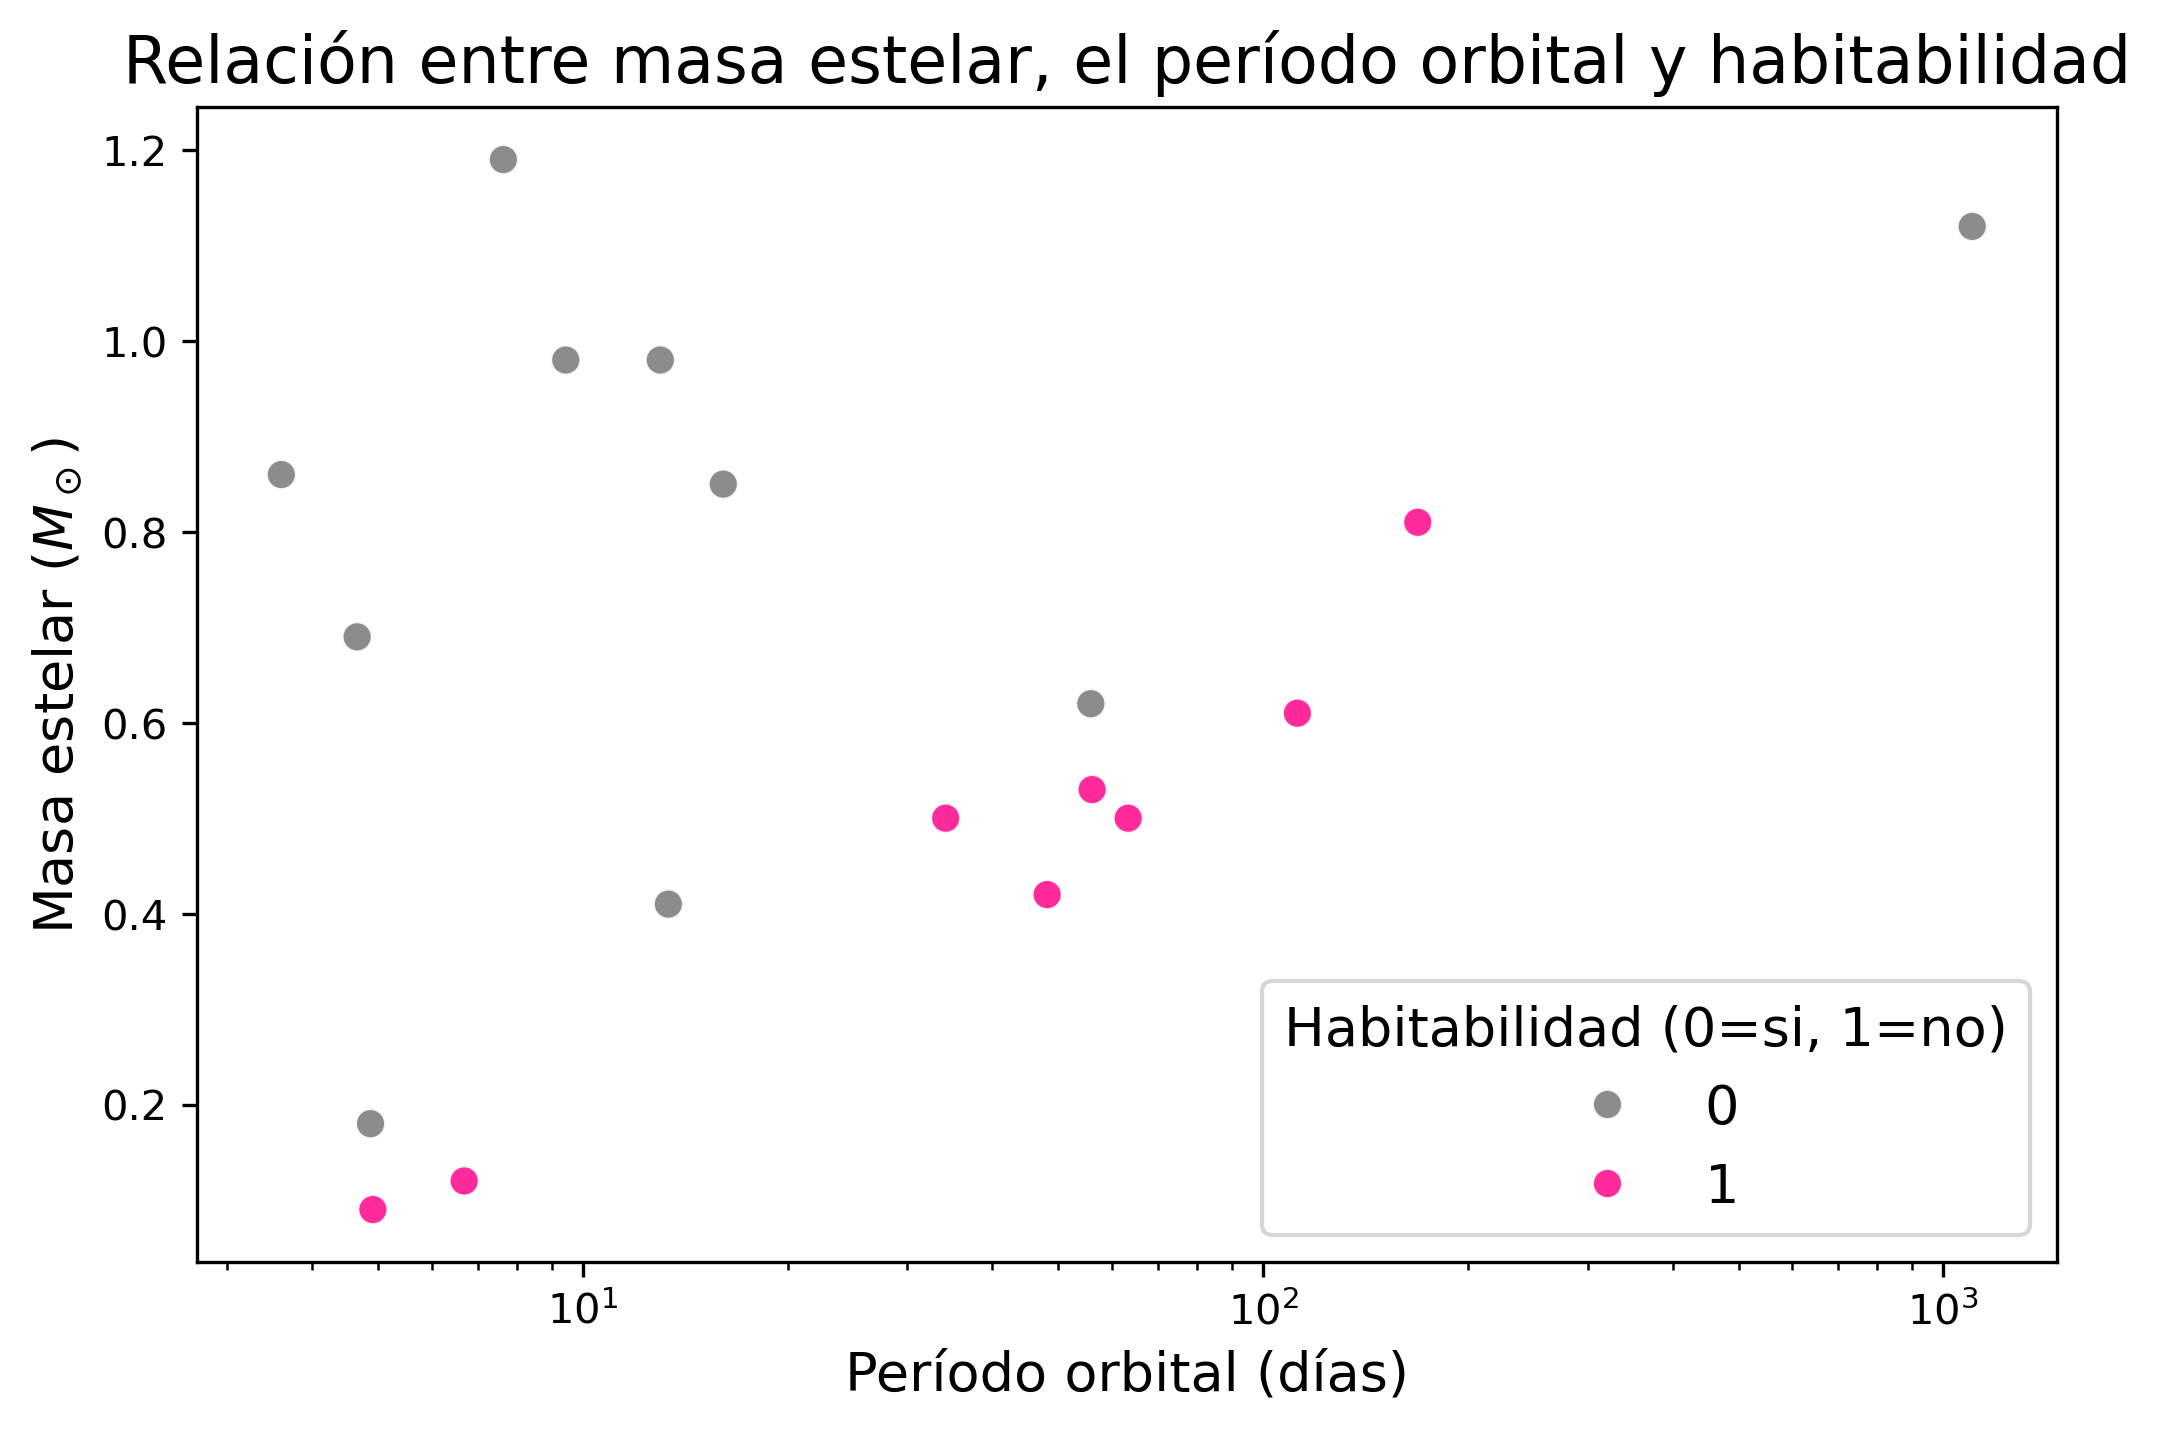

In [21]:
#Siguiendo el modelo de la actividad 2 para relacionar entre variables se puede utilizar sns
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=LearningSet,
    x="P_PERIOD",
    y="S_MASS",
    hue="P_HABITABLE",
    palette={0: "gray", 1: "deeppink"},
    alpha=0.9,
    s=50,
)
plt.xscale("log") #esto es como para simplificar la notación, para hacer del período una estimación
plt.xlabel("Período orbital (días)")
plt.ylabel(r"Masa estelar ($M_\odot$)")
plt.title("Relación entre masa estelar, el período orbital y habitabilidad")
plt.legend(title="Habitabilidad (0=si, 1=no)")
plt.show()

<h2 style="color:Fuchsia; font-family:; text-align:center;font-size:25px">
  ❁۪ ｡˚ Eligiendo el set de entrenamiento y prueba ❁۪ ｡˚
</h2>

Para definir los sets de entrenamiento y prueba, se hace una división *manual*

Se pueden definir las primeras 13 filas del dataframe como el conjunto de entrenamiento y los últimos 5, el conjunto de prueba

> En un problema real, usualmente se prefiere una división aleatoria o validación cruzada.

Usaremos .iloc para acceder a los índices del dataframe

In [22]:
LearningSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [23]:
TrainSet =  LearningSet.iloc[:13,:]  
TestSet = LearningSet.iloc[13:,:]

In [24]:
TrainSet #esto muestra los primeros 13 elementos

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [26]:
TestSet #esto muestra los últimos 5 elementos que son de prueba

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
13,HD 104067 b,0.62,55.80600,0.260000,0
14,GJ 4276 b,0.41,13.35200,0.087613,0
15,Kepler-296 f,0.50,63.33627,0.268885,1
16,Kepler-63 b,0.98,9.43415,0.088100,0
17,GJ 3293 d,0.42,48.13450,0.195336,1


Además se definen para cada conjunto las características (features) y los objetivos (targets)

In [27]:
Xtrain = TrainSet.drop(['P_NAME','P_HABITABLE'],axis=1) #features conjunto de entrenamiento
Xtest = TestSet.drop(['P_NAME','P_HABITABLE'],axis=1) #features conjunto de entrenamiento

In [28]:
Xtrain.columns

Index(['S_MASS', 'P_PERIOD', 'P_DISTANCE'], dtype='str')

In [29]:
ytrain = TrainSet.P_HABITABLE #target conjunto prueba
ytest = TestSet.P_HABITABLE  #target conjunto prueba

In [32]:
Xtest

,S_MASS,P_PERIOD,P_DISTANCE
13,0.62,55.80600,0.260000
14,0.41,13.35200,0.087613
15,0.50,63.33627,0.268885
16,0.98,9.43415,0.088100
17,0.42,48.13450,0.195336


In [33]:
ytrain #esto es la habitabilidad y no habitabilidad del exoplaneta

0     0
1     0
2     0
3     1
4     0
5     1
6     0
7     1
8     0
9     1
10    1
11    1
12    0
Name: P_HABITABLE, dtype: int64

<h2 style="color:Fuchsia; font-family:; text-align:center;font-size:25px">
  ❁۪ ｡˚ Entrenando el modelo ❁۪ ｡˚
</h2>
Nota: En los árboles de decisión de scikit-learn, las características (o variables) se reorganizan aleatoriamente cada vez que se realiza una división para decidir cómo separar los datos. Esto significa que, incluso si se usa el mismo conjunto de datos de entrenamiento, la mejor forma de dividir los datos puede cambiar entre diferentes ejecuciones del modelo. Esta variación ocurre cuando varias divisiones posibles ofrecen la misma mejora en el criterio de evaluación (por ejemplo, reducir la impureza del nodo). En estos casos, el algoritmo puede elegir diferentes divisiones como "mejores" en diferentes ejecuciones debido al orden aleatorio en que se evalúan las características.

Para asegurar que los resultados del entrenamiento sean consistentes y reproducibles (es decir, que se obtenga el mismo árbol de decisión cada vez que se entrene con los mismos datos), es necesario fijar el parámetro random_state. Esto establece una semilla para el generador de números aleatorios utilizado por el algoritmo, garantizando que la permutación de las características sea la misma en cada ejecución y, por lo tanto, el resultado del modelo también sea el mismo.

In [34]:
from sklearn.tree import DecisionTreeClassifier #modelo de árbol de decisión

In [35]:
#Se inicializa el modelo con sus parámetros
model = DecisionTreeClassifier(random_state = 3) 
model.fit(Xtrain, ytrain) #En una línea, construimos el modelo

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",3
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

<h2 style="color:Fuchsia; font-family:; text-align:center;font-size:25px">
  ❁۪ ｡˚ Podemos visualizar el árbol (visualización "pro") ❁۪ ｡˚
</h2>
Instalando la libreria [`pydotplus`](https://pypi.org/project/pydotplus/)  y [`graphviz`](https://pypi.org/project/graphviz/) 

In [21]:
!pip install pydotplus

In [26]:
!pip install graphviz

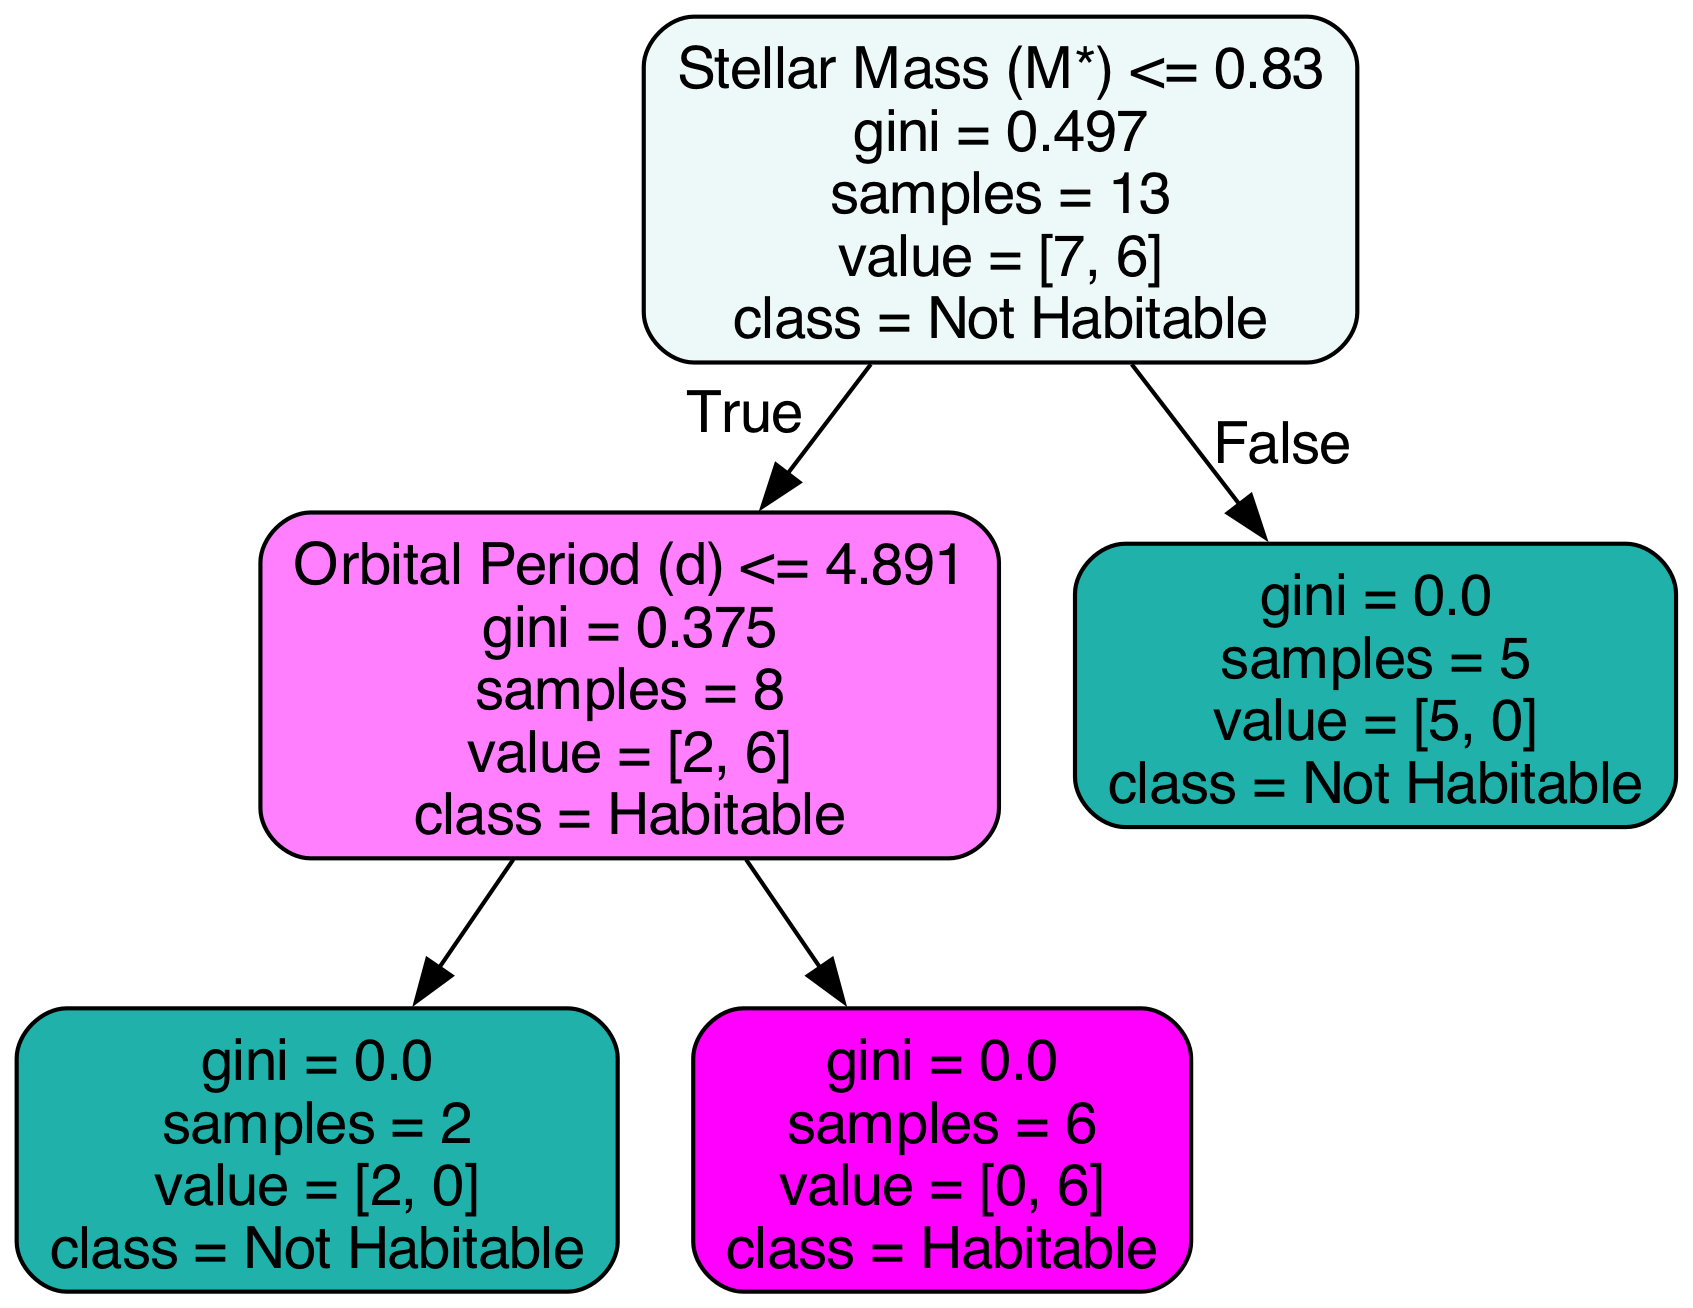

In [36]:
dot_data = StringIO()
export_graphviz(
            model,
            out_file =  dot_data,
            feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
            class_names = ['Not Habitable','Habitable'],
            filled = True,
            rounded = True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))  
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label():
        values = [int(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [255 * v / sum(values) for v in values]
        
        values = [int(255 * v / sum(values)) for v in values]
            
        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha) #turn into hexadecimal
            color = '#20 B2 AA'+str(alpha)
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#FF 00 FF'+str(alpha)
        node.set_fillcolor(color)
graph.set_dpi('300')
Image(graph.create_png())
#Image(graph.write_png('Graph.png'))

A través del árbol de decisión (además de relacionar con la gráfica de period vs stellar mass) se pueden proveer los splits a partir de la raíz, que en este caso es que los elementos del set de entrenamiento tengan masa estelar menor o igual a 0.83 masas solares (aquello forma más adelante en el gráfico un segundo split hacia la izquierda). Para la raíz existen 13 elementos del set de entrenamiento, 7 están en el lado turquesa y 6 en el rosado, lo que permite obtener el gini como fracción de impureza como 1 -((6/13)**2+(7/13)**2)=0.497. Si eso se cumple, se establece una nueva división para elementos que tengan período orbital menor o igual a 4.891 días, cuyo gini es 0.375, donde se tienen 8 elementos train, de los cuales 2 caen en el lugar de no habitables y 6 caen en habitables y si se quiere que sean habitables, entonces se desplegan 2 divisiones más como nodos finales, donde la impureza se hace 0 porque los elementos están en el lugar correcto y 2 de ellos son no habitables, para el otro caso también hay una fracción de impureza 0, puesto que 6 elementos del train caen en el lugar correcto. Pero volviendo al caso de que no sea verdad, al false part, se tiene un gini de 0, dado que 5 elementos del train set caen en el lugar correcto (turquesa).

<h2 style="color:Fuchsia; font-family:; text-align:center;font-size:25px">
  ❁۪ ｡˚ Visualización de sklearn ❁۪ ｡˚
</h2>

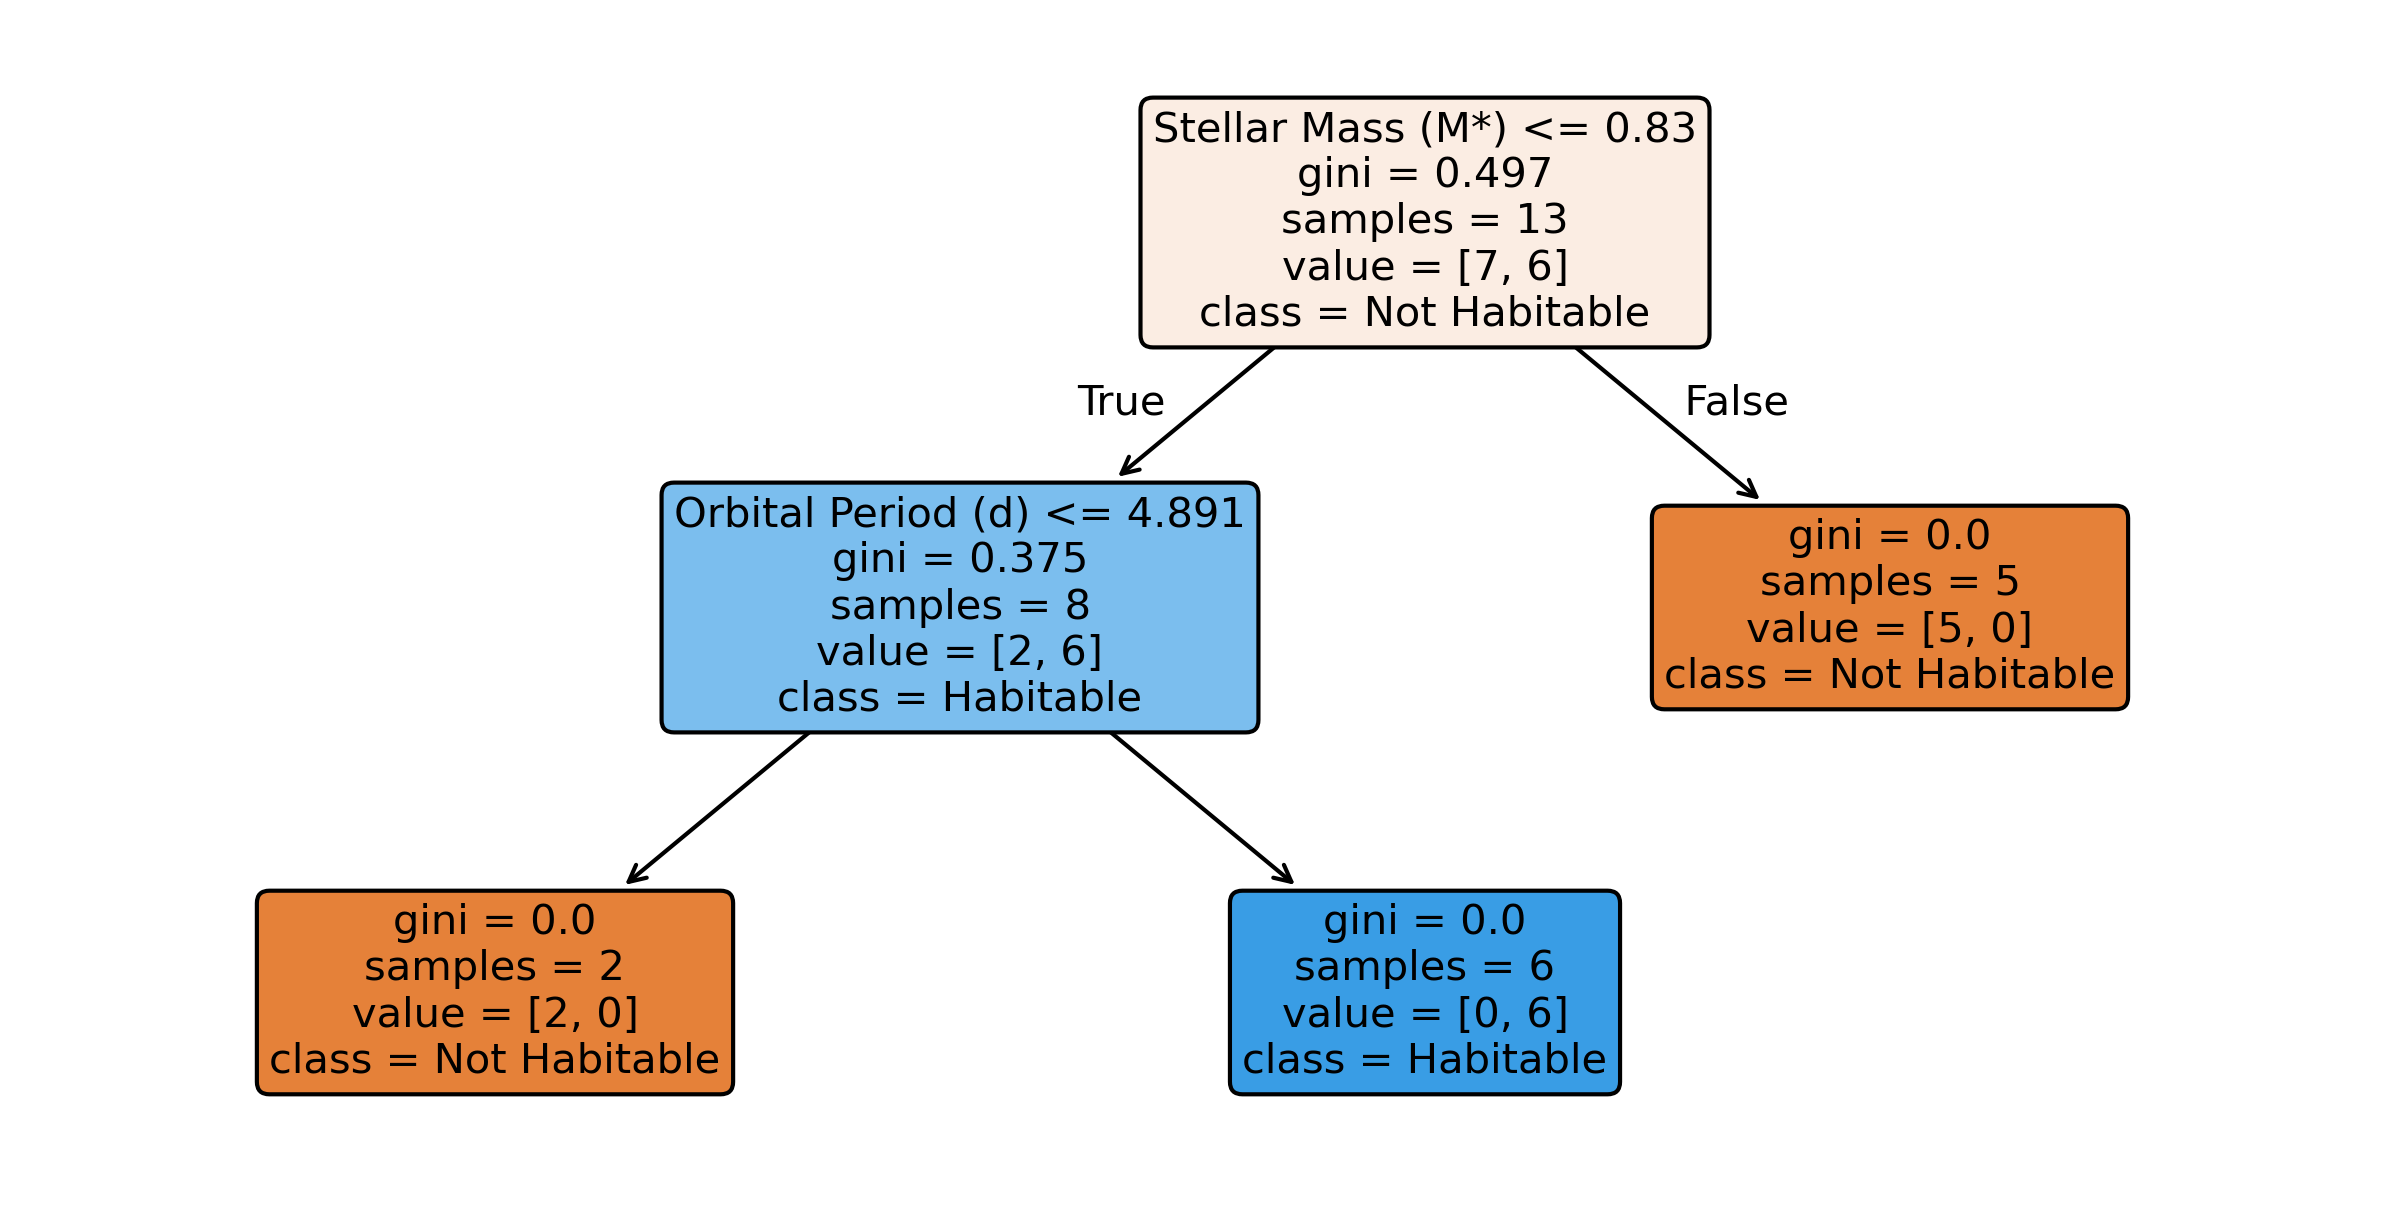

In [71]:
from sklearn import tree

plt.figure(figsize=(10,5))  # puede cambiar de acuerdo al tamaño del árbol
tree.plot_tree(model,
               feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
               class_names = ['Not Habitable','Habitable'],
               filled=True,
               rounded=True,
               fontsize=10)

plt.show()

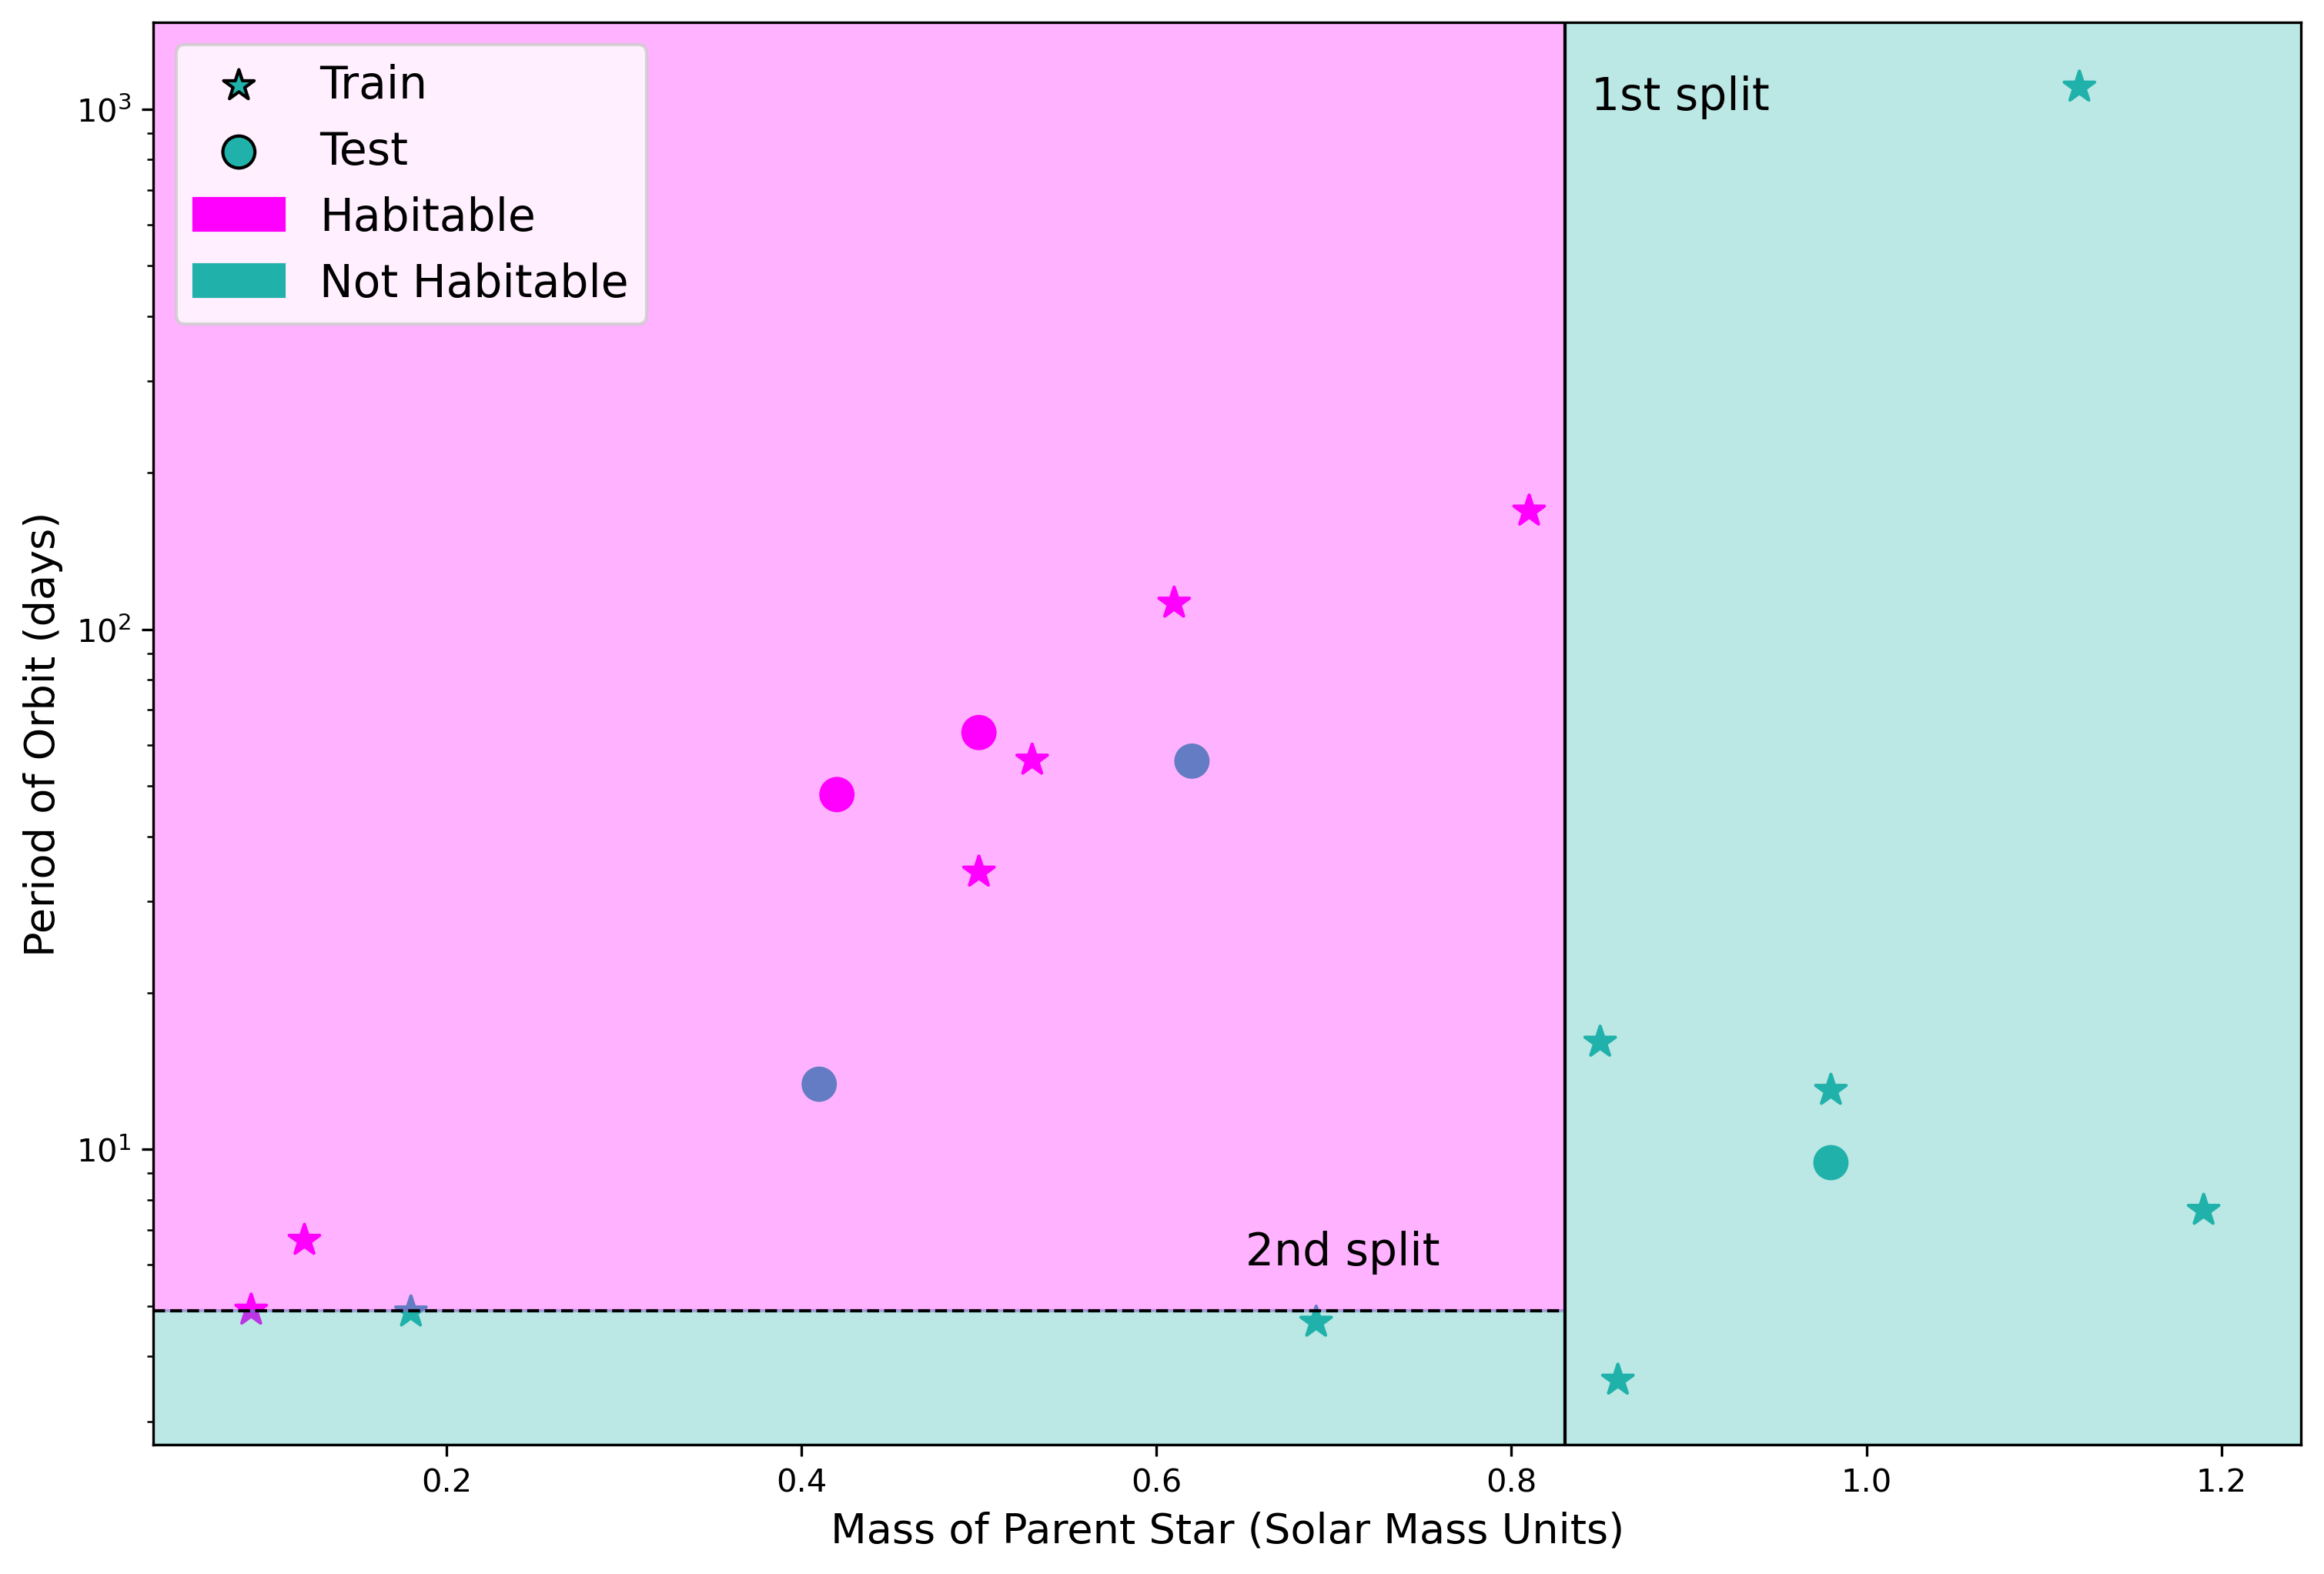

In [37]:
plt.figure(figsize=(12,8))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

#puntos de entrenamiento y prueba
plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',\
            c = TrainSet['P_HABITABLE'], s = 100, cmap=cmap, label = 'Train')

plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',\
            c = TestSet['P_HABITABLE'], s = 100, cmap=cmap, label = 'Test')

plt.yscale('log')
plt.xlabel('Mass of Parent Star (Solar Mass Units)')
plt.ylabel('Period of Orbit (days)');
#splits del gráfico
plt.axvline(x=0.83, linewidth =1, ls = '-', label = '1st split', c='k')

plt.axhline(y=4.891, xmin = 0, xmax = 0.655, linewidth =1, ls = '--', label = '2nd split',c='k')

plt.text(0.845, 10**3, '1st split', fontsize=14)
         
plt.text(0.65, 6, '2nd split', fontsize=14)

#leyenda

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')
plt.legend();
ax = plt.gca()
predhab = mpatches.Rectangle((0,4.891),0.83,ax.get_ylim()[1], 
                        fill = True,
                        color = '#FF00FF',
                        alpha = 0.3)

prednothab1 = mpatches.Rectangle((0.83,ax.get_ylim()[0]),ax.get_xlim()[1],ax.get_ylim()[1], 
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

prednothab2 = mpatches.Rectangle((0,ax.get_ylim()[0]),0.83,4.891-ax.get_ylim()[0], 
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)
leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')
plt.gca().add_patch(predhab)
plt.gca().add_patch(prednothab1)
plt.gca().add_patch(prednothab2)
leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')
plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14);

Como se puede observar en el gráfico, se tienen fondos de colores para indicar la habitabilidad y no habitabilidad, en donde considerando el set de entrenamiento todos sus elementos caen correctamente a la clasificación por color, pero no ocurre para dos elementos del set de prueba los que son no habitables y caen en el split de habitables.


<h2 style="color:Fuchsia; font-family:; text-align:center;font-size:25px">
  ❁۪ ｡˚ Construyendo otro ejemplo de set  ❁۪ ｡˚
</h2>
Las 5 primeras filas serán de prueba y el resto (13) será para el entrenamiento

<h2 style="color:Fuchsia; font-family:; text-align:center;font-size:17px">
  ❁۪ ｡˚Repitiendo el proceso anterior   ❁۪ ｡˚
</h2>

1. Definiendo los dataframes de características y la serie de categorías para entrenamiento y prueba: `Xtrain2`, `Xtest2`, `ytrain2`, `ytest2`

2. Inicializando el modelo de árbol de decisión para clasificación (definiendo semilla `random_state=3`)
3. Ajustando el modelo a los datos de entrenamiento
4. Visualice el árbol
5. Calculando el accuracy para entrenamiento y prueba

In [91]:
# los primeros 5 de prueba, el resto de entrenamiento
TrainSet2 = LearningSet.iloc[5:,:] 
TestSet2 = LearningSet.iloc[:5,:]

In [92]:
#Se puede construir otro set de entrenamiento y prueba
Xtrain2 = TrainSet2.drop(['P_NAME','P_HABITABLE'],axis=1) #features conjunto de entrenamiento
Xtest2 = TestSet2.drop(['P_NAME','P_HABITABLE'],axis=1) #features  conjunto de entrenamiento

In [93]:
Xtrain2.columns

Index(['S_MASS', 'P_PERIOD', 'P_DISTANCE'], dtype='str')

In [94]:
ytrain2 = TrainSet2.P_HABITABLE #target conjunto prueba
ytest2 = TestSet2.P_HABITABLE #target conjunto prueba

In [95]:
Xtest2

,S_MASS,P_PERIOD,P_DISTANCE
0,0.86,3.601472,0.043718
1,0.85,16.080661,0.118082
2,1.19,7.638460,0.080420
3,0.61,112.305300,0.409327
4,0.98,12.992073,0.107408


In [96]:
ytrain2

5     1
6     0
7     1
8     0
9     1
10    1
11    1
12    0
13    0
14    0
15    1
16    0
17    1
Name: P_HABITABLE, dtype: int64

In [116]:
model2 = DecisionTreeClassifier(random_state = 3) #definiendo modelo 2 para no superponer datos, esto en estado 3
#Inicializamos el modelo con sus parámetros
model2.fit(Xtrain2, ytrain2) #En una línea, construimos el modelo

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",3
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

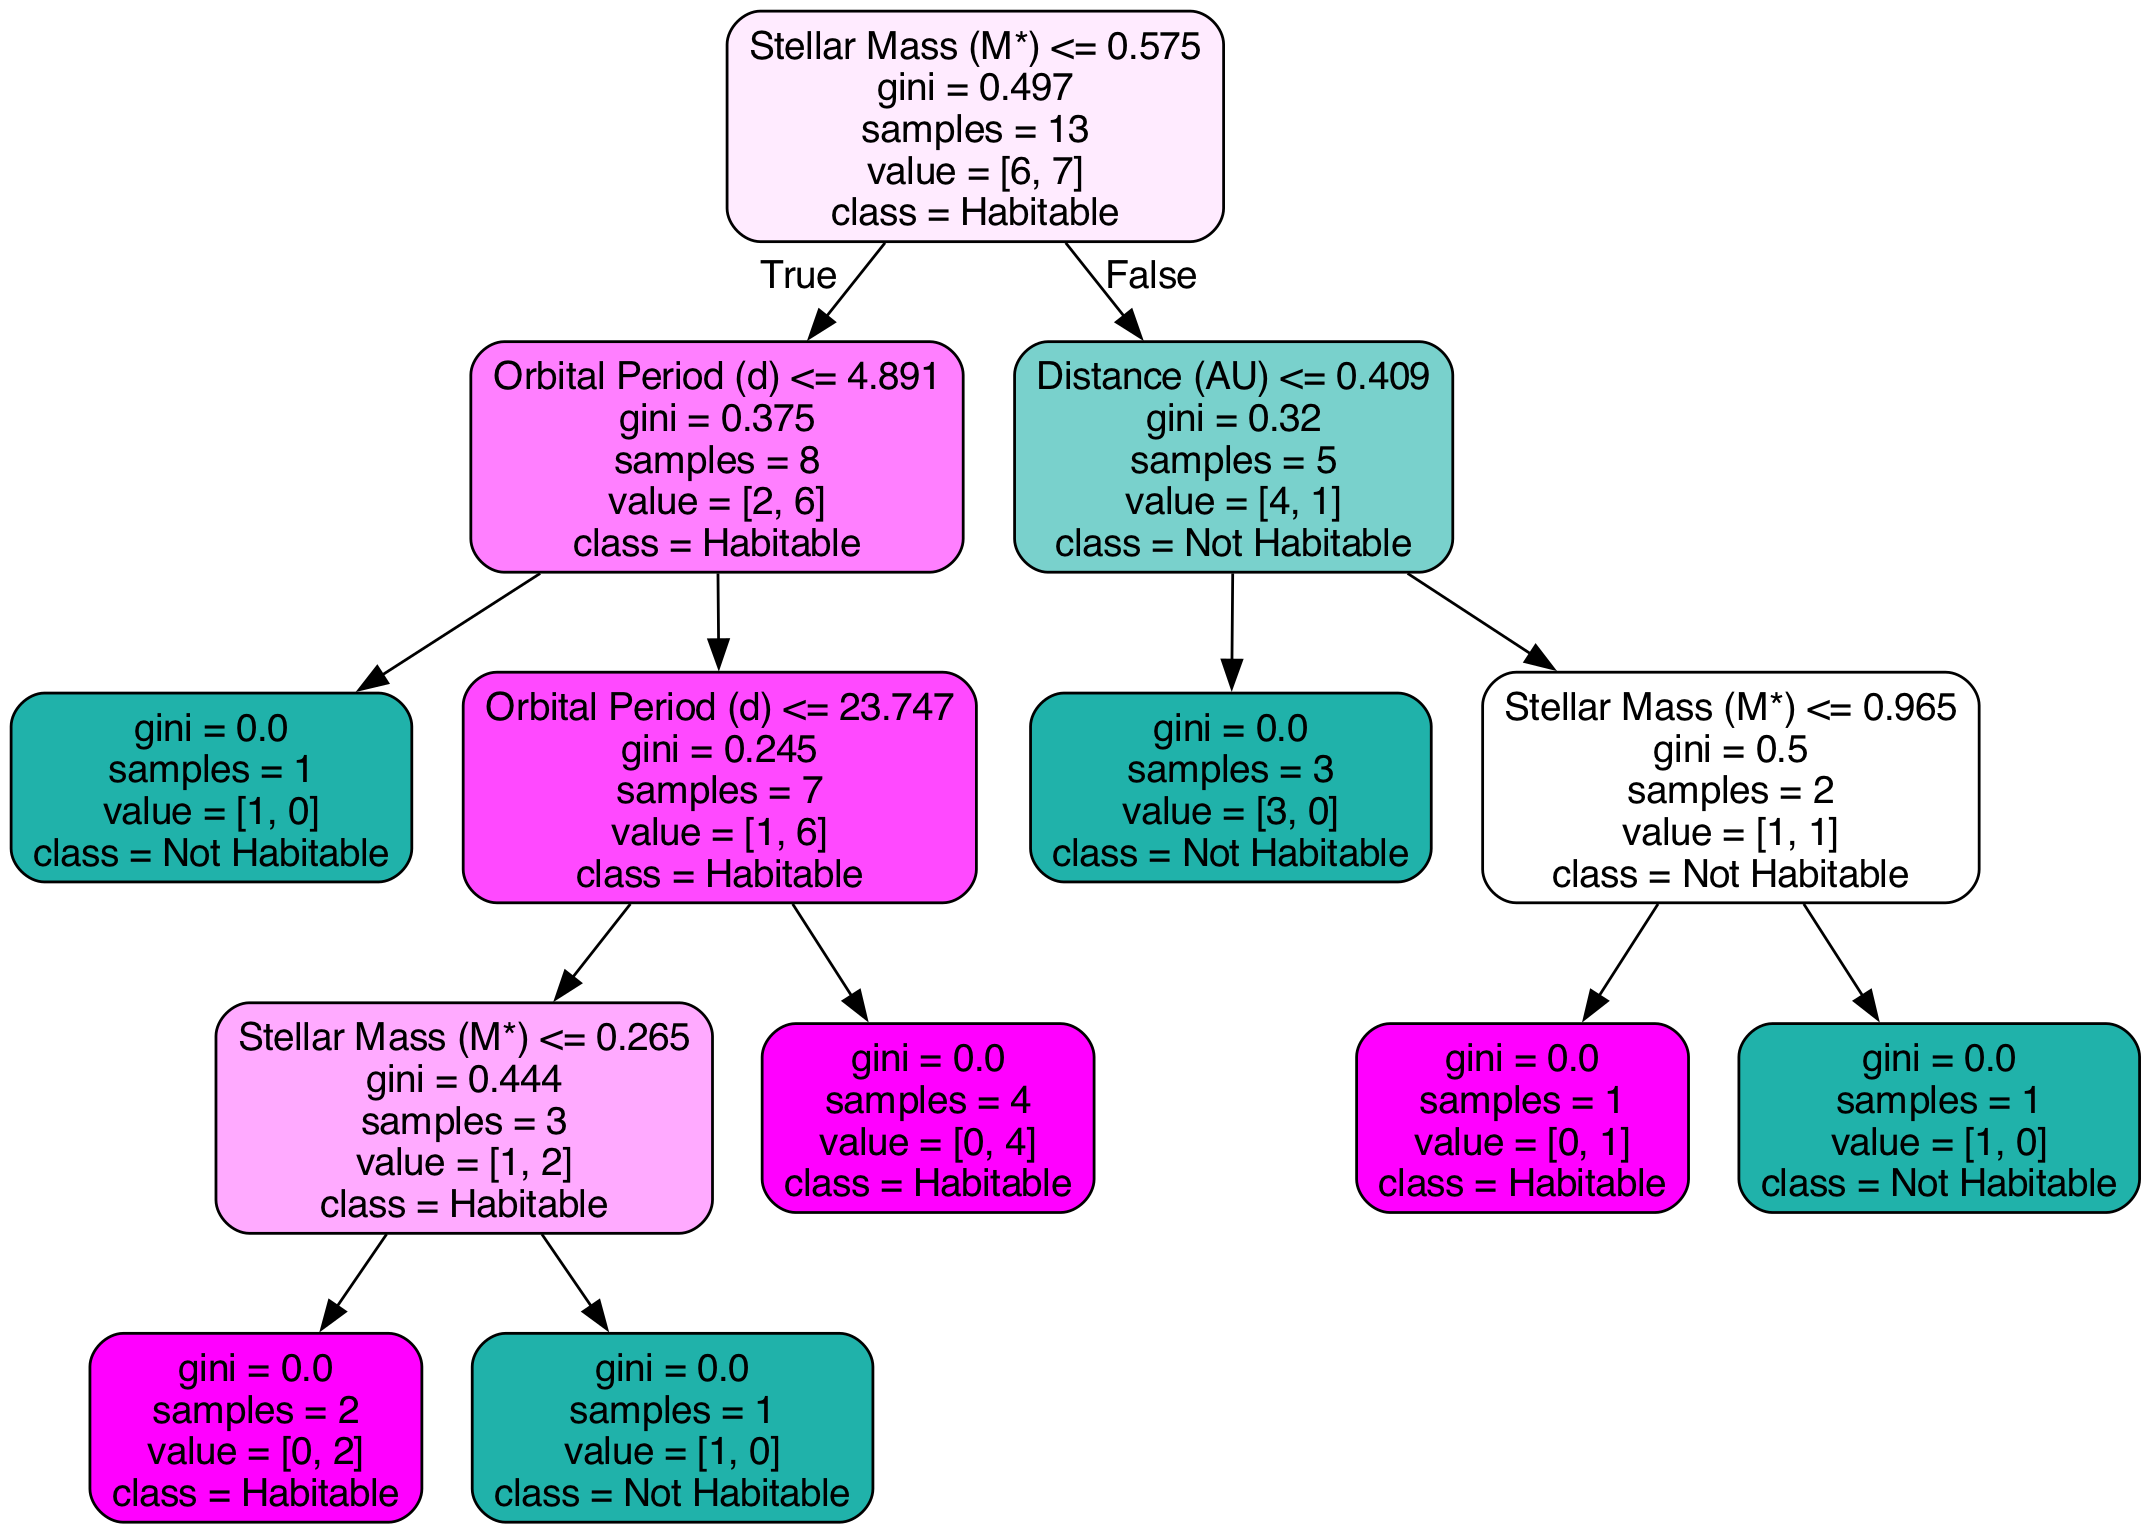

In [117]:
dot_data2 = StringIO()
export_graphviz(
            model2,
            out_file =  dot_data2,
            feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
            class_names = ['Not Habitable','Habitable'],
            filled = True,
            rounded = True)
graph = pydotplus.graph_from_dot_data(dot_data2.getvalue().replace("\n", ""))  
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label():
        values = [int(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [255 * v / sum(values) for v in values]
        
        values = [int(255 * v / sum(values)) for v in values]
            
        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha) #turn into hexadecimal
            color = '#20 B2 AA'+str(alpha)
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#FF 00 FF'+str(alpha)
        node.set_fillcolor(color)
graph.set_dpi('200')
Image(graph.create_png())
#Image(graph.write_png('Graph.png'))

Como se puede ver en el árbol de decisión, se tiene una división más profunda cuando se utilizan 5 datos de prueba en comparación con con los 13 datos de prueba en el primer caso. 

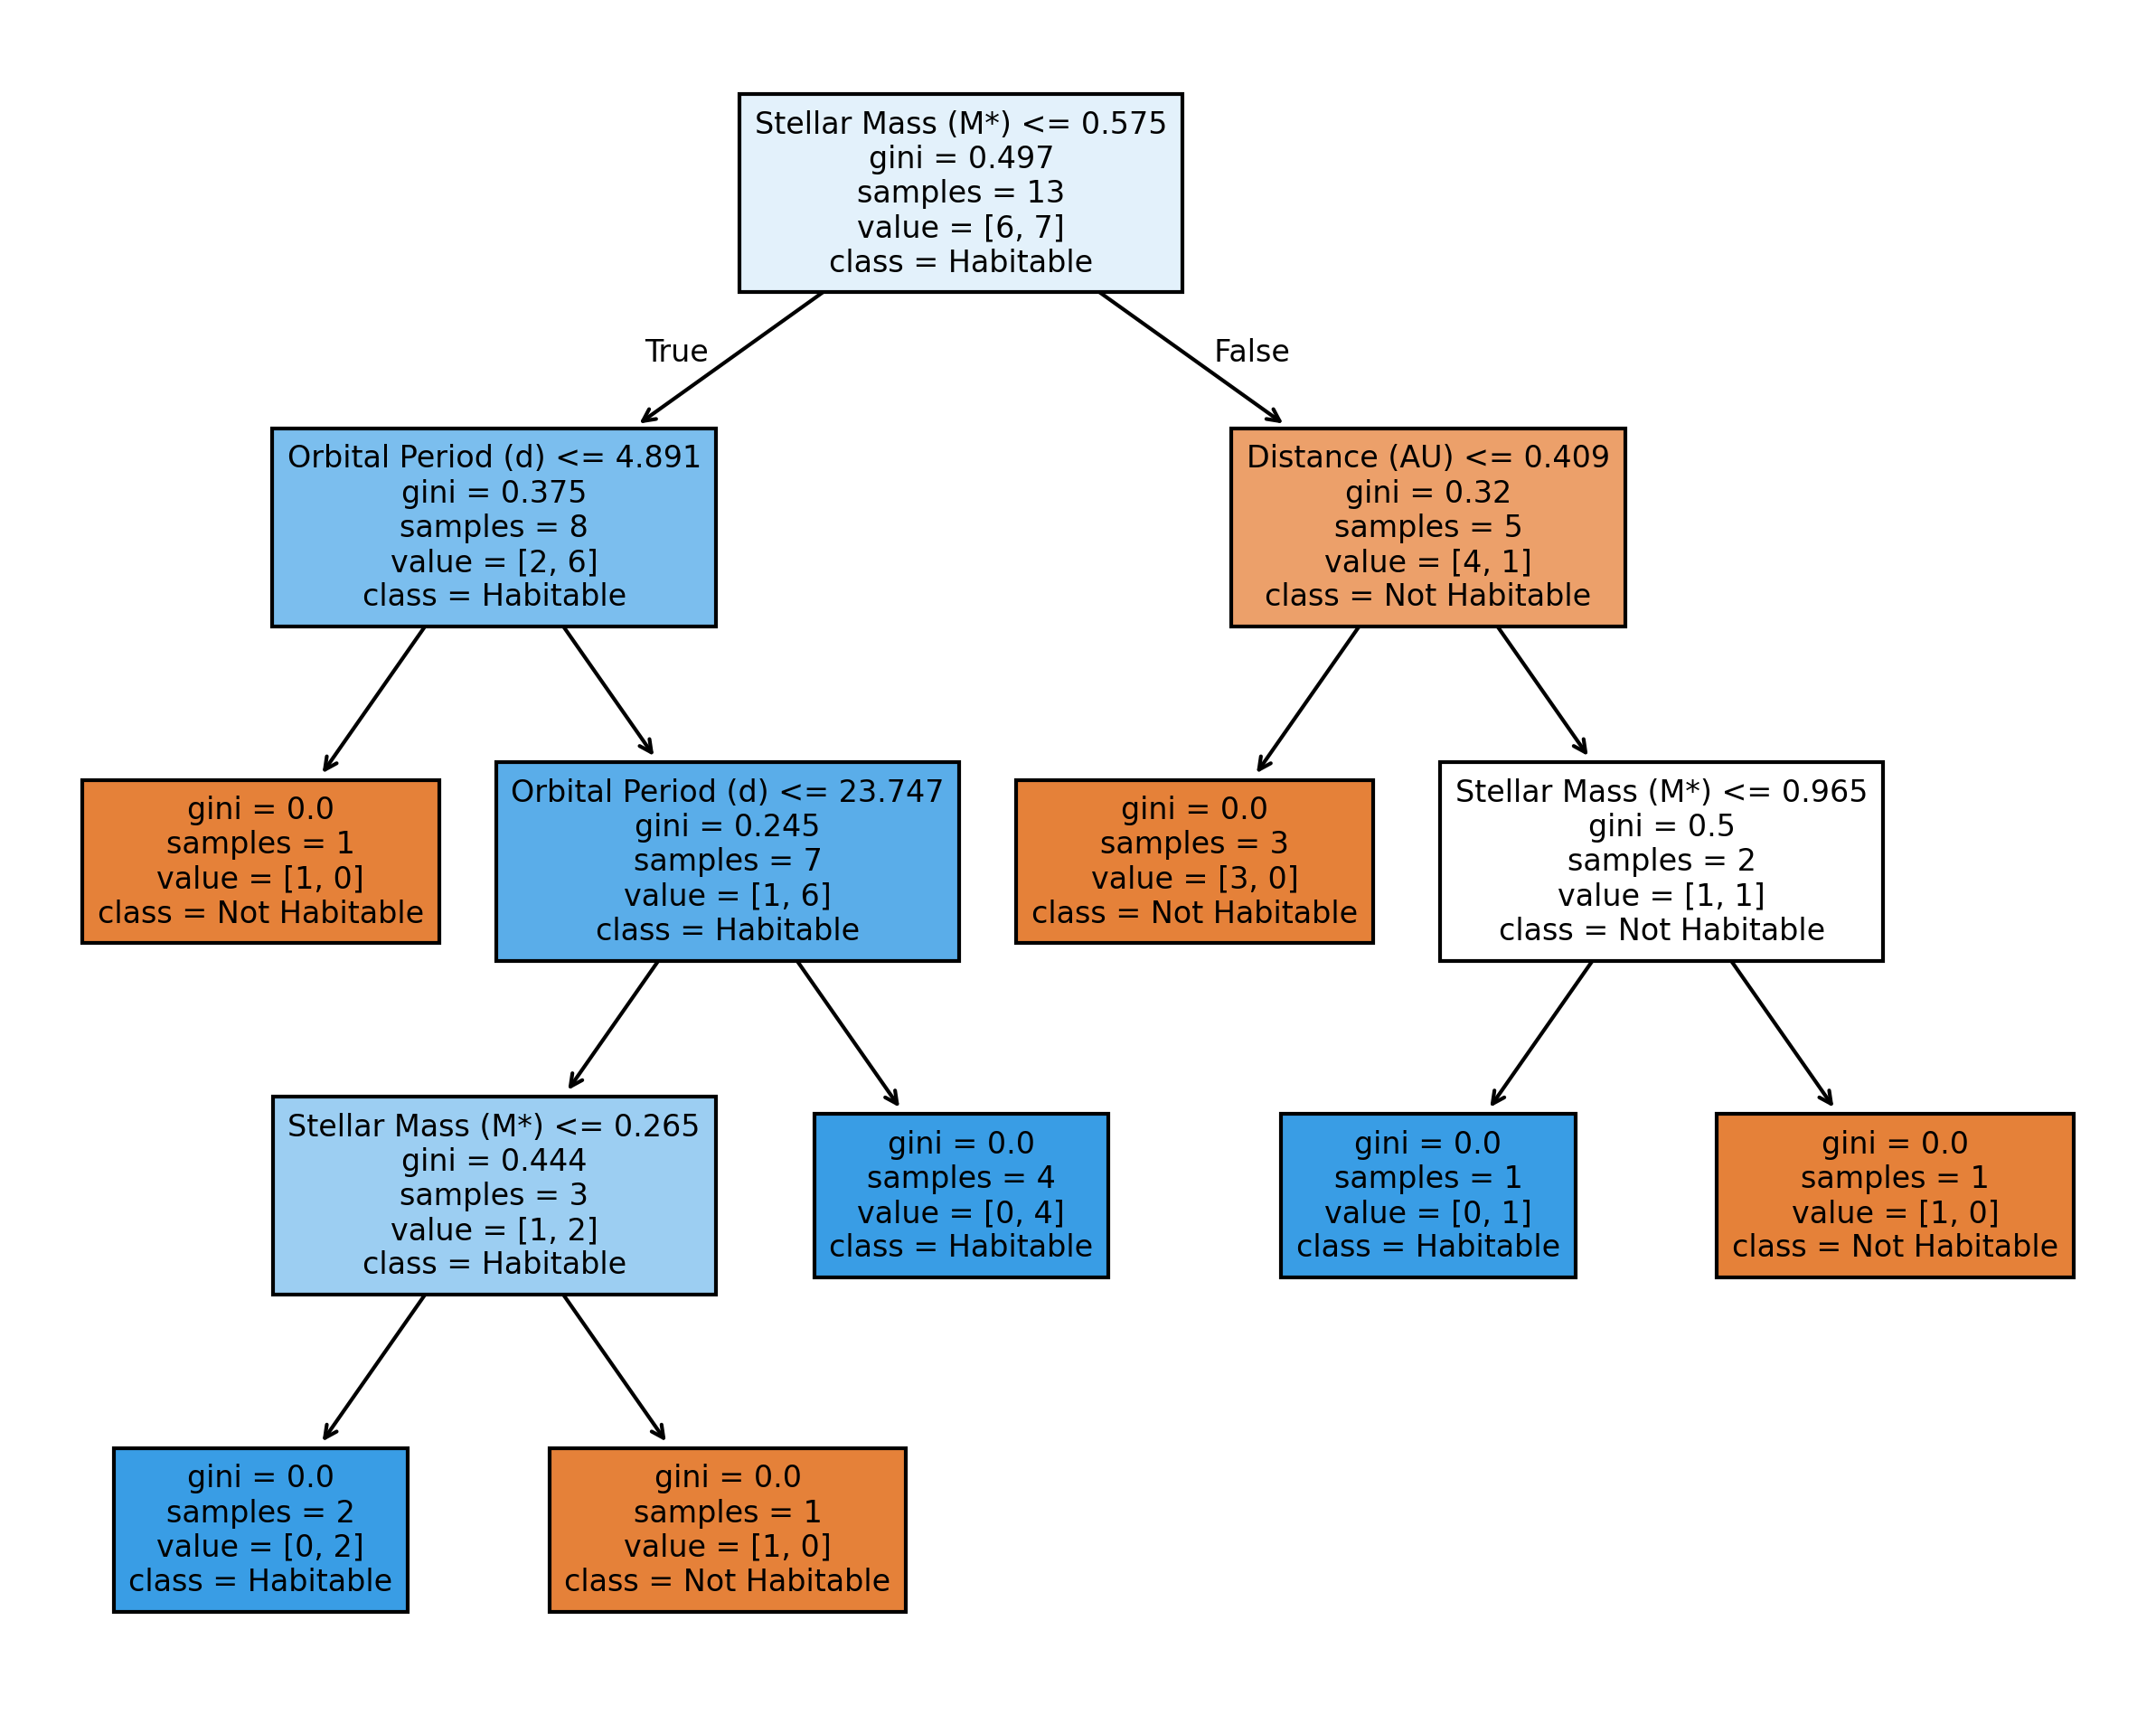

In [114]:
from sklearn import tree

plt.figure(figsize=(10,8))  # puede cambiar de acuerdo al tamaño del árbol
tree.plot_tree(model2,
               feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
               class_names = ['Not Habitable','Habitable'],
               filled=True,
               rounded=False,
               fontsize=8)

plt.show()

### También podemos visualizar las decisiones del clasificador. El color de sombreado predice la etiqueta, y el color de los puntos marca la etiqueta real:

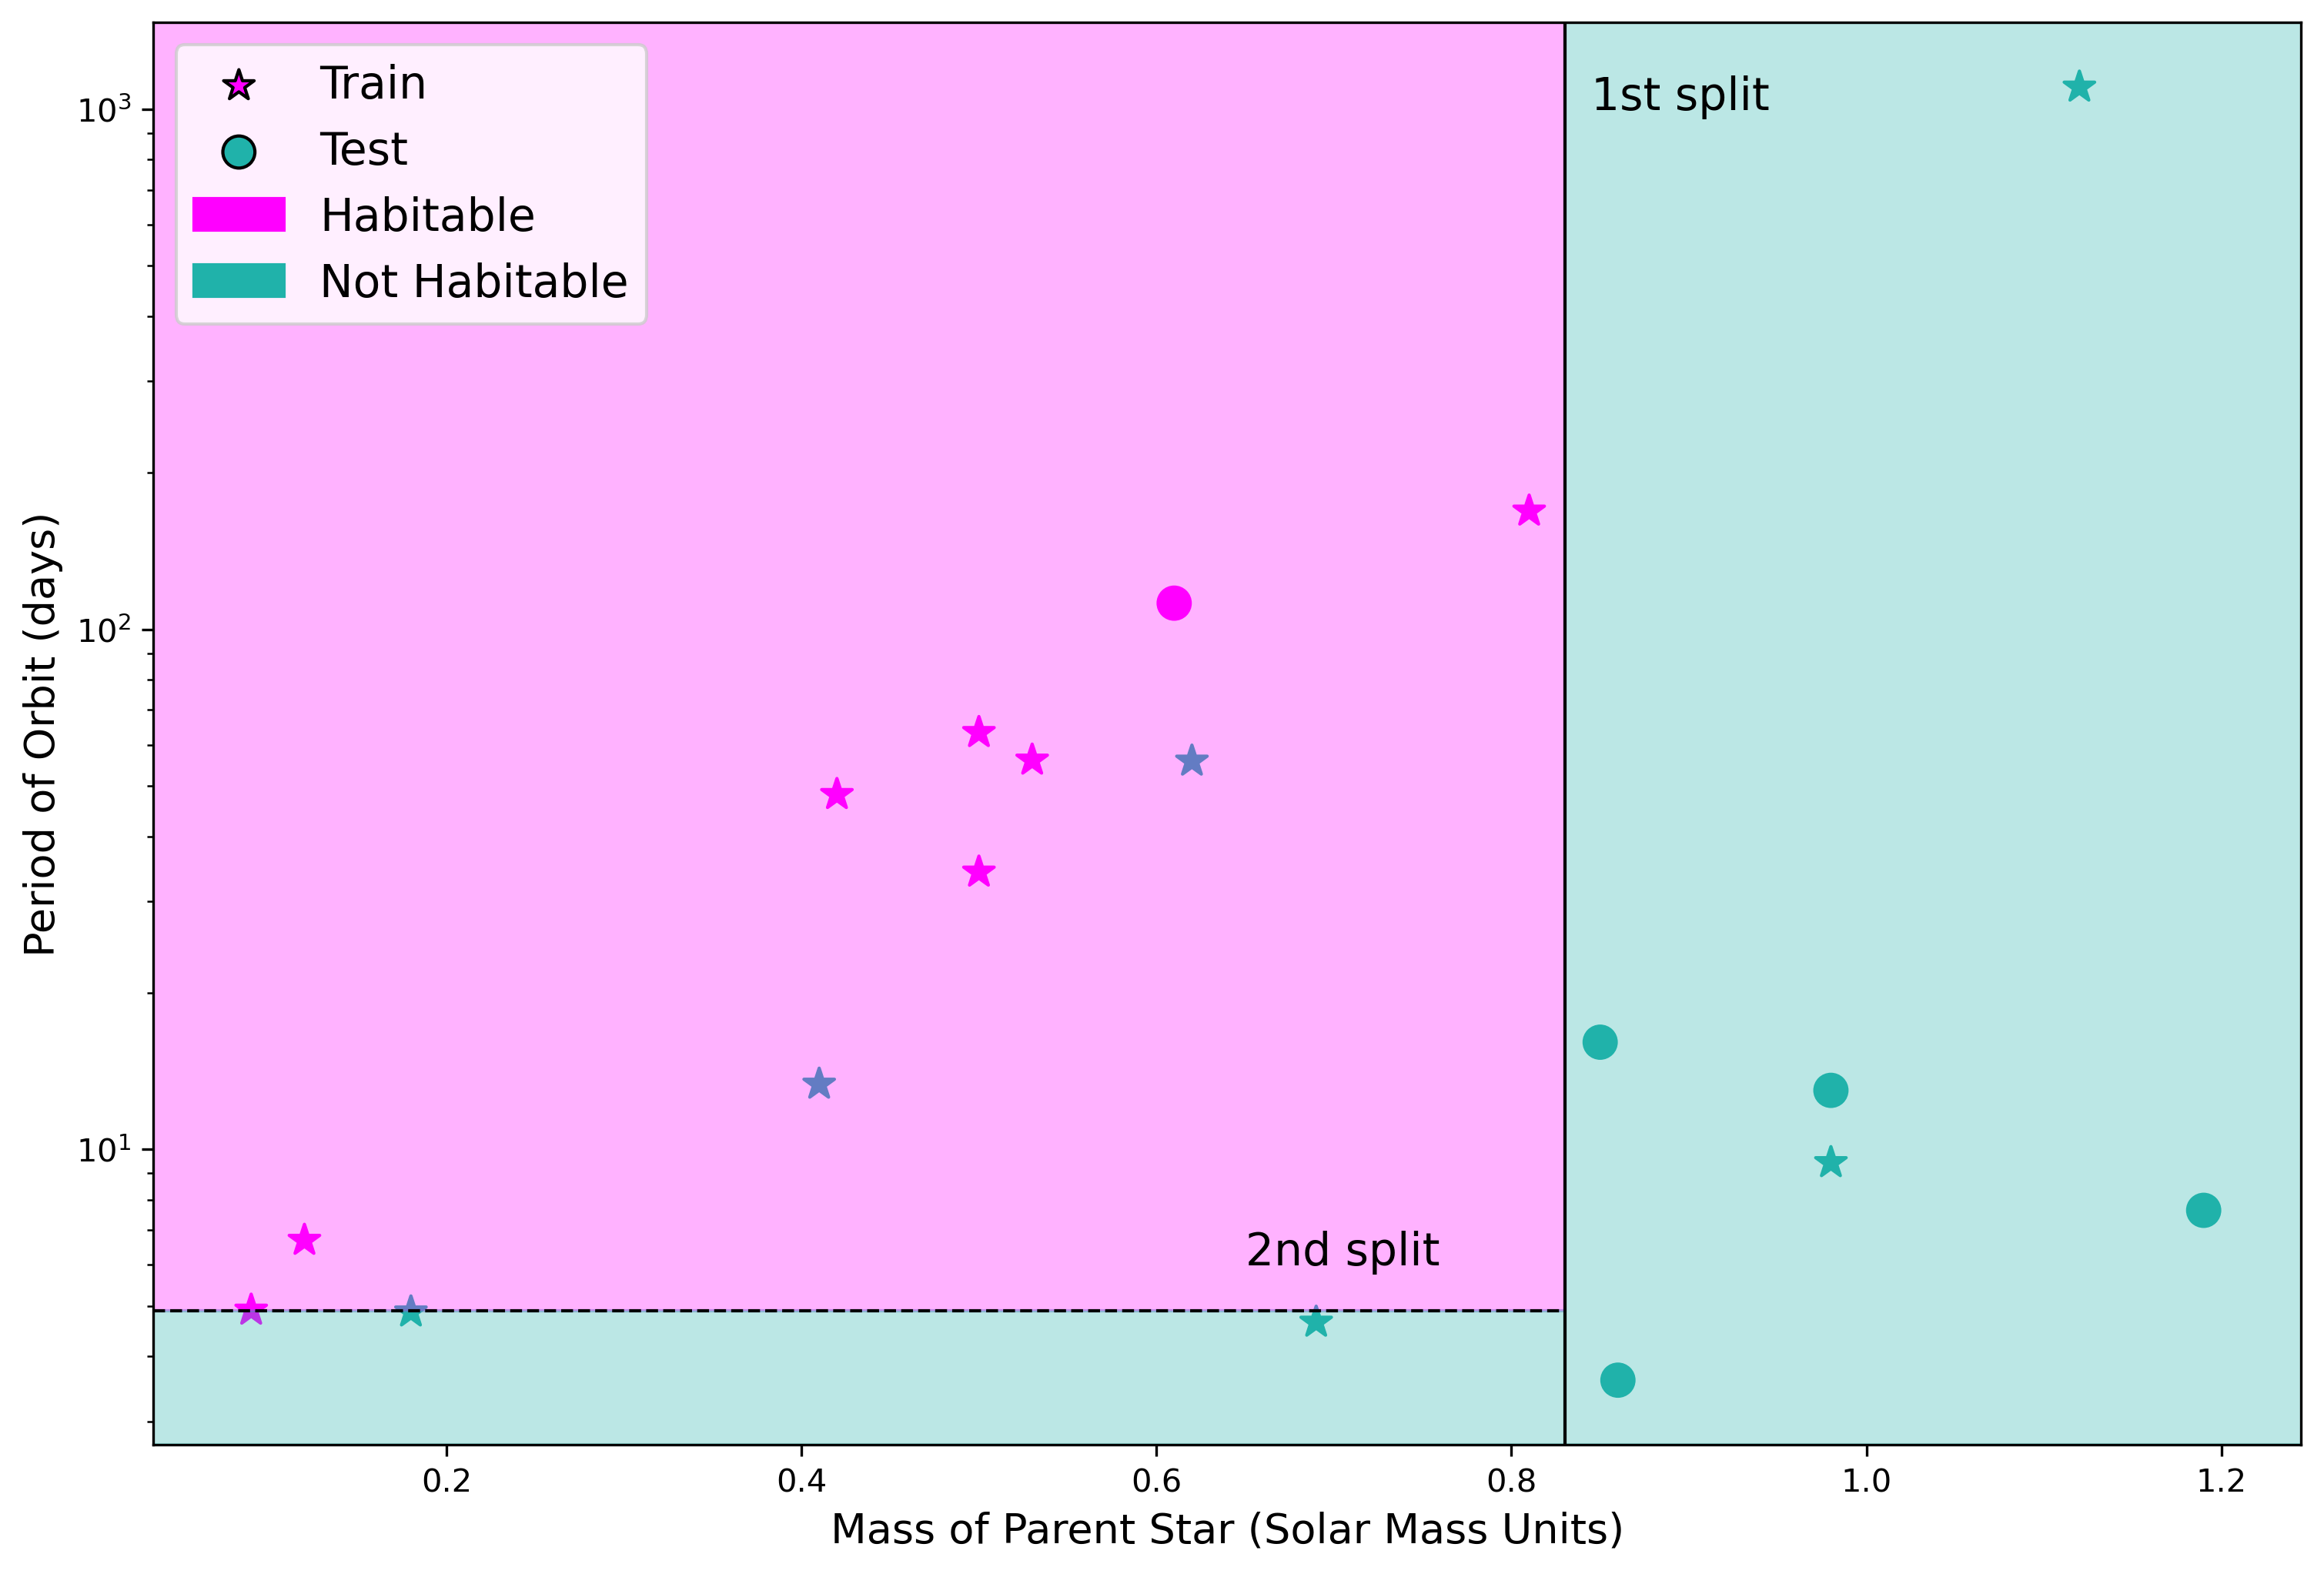

In [115]:
plt.figure(figsize=(12,8))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

#puntos de entrenamiento y prueba

plt.scatter(TrainSet2['S_MASS'], TrainSet2['P_PERIOD'], marker = '*',\
            c = TrainSet2['P_HABITABLE'], s = 100, cmap=cmap, label = 'Train')

plt.scatter(TestSet2['S_MASS'], TestSet2['P_PERIOD'], marker = 'o',\
            c = TestSet2['P_HABITABLE'], s = 100, cmap=cmap, label = 'Test')

plt.yscale('log')

plt.xlabel('Mass of Parent Star (Solar Mass Units)')

plt.ylabel('Period of Orbit (days)');

#splits del gráfico

plt.axvline(x=0.83, linewidth =1, ls = '-', label = '1st split', c='k')

plt.axhline(y=4.891, xmin = 0, xmax = 0.655, linewidth =1, ls = '--', label = '2nd split',c='k')

plt.text(0.845, 10**3, '1st split', fontsize=14)
         
plt.text(0.65, 6, '2nd split', fontsize=14)

#leyenda

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')
plt.legend();
ax = plt.gca()
predhab = mpatches.Rectangle((0,4.891),0.83,ax.get_ylim()[1], 
                        fill = True,
                        color = '#FF00FF',
                        alpha = 0.3)

prednothab1 = mpatches.Rectangle((0.83,ax.get_ylim()[0]),ax.get_xlim()[1],ax.get_ylim()[1], 
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

prednothab2 = mpatches.Rectangle((0,ax.get_ylim()[0]),0.83,4.891-ax.get_ylim()[0], 
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)
leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')
plt.gca().add_patch(predhab)
plt.gca().add_patch(prednothab1)
plt.gca().add_patch(prednothab2)
leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')
plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14);

### Pregunta 
    
- ¿Cuál es el porcentaje de clasificaciones correctas en el set de entrenamiento?  Y en el set de prueba? En el set de entrenamiento hay 7/11 correctas clasificaciones (como train) luego es aprox. 63% de clasificación acertada (aquí las 7 estrellas rosa caen en el lugar rosa, donde hay 11 elementos), y en el set de prueba hay 100% de clasificaciones correctas (los circulos turquesa caen en el lugar turquesa). 

A este porcentaje de clasificaciones correctas lo llamaremos **accuracy**

<h2 style="color:Fuchsia; font-family:; text-align:center;font-size:25px">
  ❁۪ ｡˚ Utilizando las métricas de sklearn, se puede encontrar el accuracy (como valor acertado o precisión) ❁۪ ｡˚
</h2>

In [118]:
import sklearn.metrics as metrics

In [119]:
Xtest = TestSet.drop(['P_NAME','P_HABITABLE'],axis=1)
ypred = model.predict(Xtest) #generamos etiquetas de predicción en el set de prueba
Xtest2 =TestSet2.drop(['P_NAME','P_HABITABLE'],axis=1)
ypred2 = model2.predict(Xtest2)

In [120]:
ypred,ypred2 #valor predicho para set 1 (model) y 2 (model2)

(array([1, 1, 1, 0, 1]), array([0, 0, 0, 1, 0]))

Accuracy es una métrica usual para evaluar modelos de clasificación, y hay una función en el módulo `sklearn.metrics`. Tenemos que comparar los resultados de la predicción `ypred` con los valores reales `ytest`, siempre se hace eso (comparación predicción-real).

In [125]:
metrics.accuracy_score(ytest, ypred) #test score para primer modelo

0.6

In [126]:
metrics.accuracy_score(ytest2, ypred2) #test score para segundo modelo

1.0

también podemos encontrar el accuracy de los datos de entrenamiento, generando predicciones para los `Xtrain` y comparando con el `ytrain`

In [123]:
metrics.accuracy_score(ytrain, model.predict(Xtrain)) #train score para primer set

1.0

In [124]:
metrics.accuracy_score(ytrain2, model2.predict(Xtrain2)) #train score para segundo set

1.0

<h2 style="color:Fuchsia; font-family:; text-align:center;font-size:25px">
  ❁۪ ｡˚Preguntas de interpretación ❁۪ ｡˚
</h2>
En primer lugar, teniendo los accuracy para ambos modelos (model y model2), se tiene que el accuracy para el set de prueba de model es de 60% y para el set de entrenamiento es de 100%, mientras que para el de model2, resulta 100% tanto para el set de prueba como para el de entrenamiento
1. ¿El árbol clasifica perfectamente el conjunto de entrenamiento? Se podría decir que sí, pero se tiene que tener precaución en por ejemplo que en el set de prueba para el último modelo (model2) se trabaja con muy pocos datos, lo que aunque de como accuracy 100% quizás no podría ser representativo del todo.
2. ¿Qué ocurre en el conjunto de prueba? Como había mencionado, el último modelo contiene un accuracy de 100%, pero se trabajan con muy pocos datos (apenas 5).
3. ¿Qué variable aparece en la raíz del árbol? En la raíz del árbol para ambos modelos, es la masa estelar (Stellar Mass [Solar Mass]). En donde para el model (primero) se clasifica para exoplanetas con masas estelares menores o igual a 0.83, y para el model2 (segundo) se clasifica con masa estelar menor o igual a 0.575.
4. ¿Te parece que este árbol es simple o ya es relativamente profundo para un dataset tan pequeño? A pesar del dataset pequeño, el árbol del último modelo es profundo, entonces conlleva a que al establecer un set tanto de entrenamiento y prueba distinto, puede impactar significativamente en un modelo distinto, variando tanto porcentajes como accuracy y variables con distintas tendencias.

### Preguntas:

- Compare el árbol de decisión inicial vs el obtenido ahora. Nota alguna diferencia?

Para el árbol de decisión inicial (model) se observan claramente menos ramas, mientras que en el obtenido en el modelo como model2, el árbol tiene muchas más divisiones por los diversos niveles de impureza. Por ejemplo, en el primer árbol se tiene una raíz de masa estelar menor o igual a 0.83, lo que conlleva a tener un gini de 0.497, considerando 13 datos. Al usar solo 2 de 3 características, porque se tienen tanto la masa estelar, el período orbital, y la distancia, pero se toman en cuenta los 2 primeros. Desde la masa estelar se realizan 2 splits con verdadero y falso si es que se cumple la predicción hecha en el set de entrenamiento. Cada nodo terminal tiene una pureza total, es decir, de 100%, para el gini=0 se tienen datos sobreajustados para claramente obtener esa pureza y así obtener no obtener error entre los datos originales con los datos que fueron entrenados. Mientras que el segundo árbol es más profundo, donde se realizan desde 2 splits, a cuatro splits. También cambia el criterio usado en los splits, dado que se están utilizando todas las características, tanto como período orbital, distancia y masa estelar. Entonces el mismo elemento, en este caso, el exoplaneta endría con distintas clasificación en ambos casos.

- ¿Cuál es el accuracy (porcentaje de clasificaciones correctas) en el conjunto de entrenamiento? Utilizando los comandos para los accuracy, hay un 100% de clasificaciones correctas para model (primer modelo, con 13 datos de entrenamiento) y model2 (con 5 datos de entrenamiento).

- ¿Y en el conjunto de prueba? Mientras que en el conjunto de prueba para el primer modelo se tiene un accuracy de 60% y en el segundo modelo se tiene un 100%.

- Si ahora el resultado es mejor, ¿significa automáticamente que este árbol es “mejor” en general? No necesariamente, puesto que si se tiene el algoritmo de la clasificación de evaluación de métrica, se podrían tener en profundidad pocos o muchos datos. Entonces si por ej. se tienen pocos datos y hay una completitud en clasificación correcta no significa que represente totalmente la muestra.


<h2 style="color:Fuchsia; font-family:; text-align:center;font-size:25px">
  ❁۪ ｡˚ Conclusiones ❁۪ ｡˚
</h2>
- Que puede concluir respecto a al ejercicio? Que al considerar tanto distintos set de entrenamiento como de prueba se obtienen distintas divisiones y purezas, impactando distinto en el modelo que se considere. Esto, al final de la clasificación involucra incertezas asociadas a un factor como el error (entre datos iniciales sacados de la tabla directamente y datos de entrenamiento), además de valores de accuracy dependientes de esos mismos sets. Aunque para poder especificar más los modelos y los splits obtenidos, se tiene que hacer un preprocesamiento, evaluación y diagnóstico de ya una cantidad muy grande de datos, dado que eso es lo que ocurre en la vida real.

- Cambian los resultados dependiendo del set de datos que utilizamos? Sí, cambian en forma de que se tomen distintos set de prueba y entrenamiento, además de la consideración de las características (como primero se tomaban en cuenta 2 de 3, y después 3 de 3).

- ¿Sería la Tierra clasificada como habitable por alguno de estos árboles? 

<h2 style="color:Fuchsia; font-family:; text-align:center;font-size:25px">
  ❁۪ ｡˚ k-Nearest Neighbors  ❁۪ ｡˚
</h2>
Aplicaremos ahora kNN al mismo problema.
kNN es un algoritmo distinto, sobre encontrar los vecinos más cercanos, clasificando según las etiquetas de estos mismos, que se pueden denominar "k" nearest neighbors. Donde se calculan las distancias entre "vecinos", por lo que la **escala** de las variables importa totalmente. Además, el método resulta útil para escoger cuál método podría tener más potencial o es más "prometedor" al momento de presentar datos y que permita analizarlos.

In [140]:
from sklearn import neighbors 
import sklearn

El método se testea para el mismo set de datos de habitabilidad de planetas

In [141]:
Xtrain

,S_MASS,P_PERIOD,P_DISTANCE
0,0.86,3.601472,0.043718
1,0.85,16.080661,0.118082
2,1.19,7.638460,0.080420
3,0.61,112.305300,0.409327
4,0.98,12.992073,0.107408
5,0.09,4.910000,0.025200
6,0.69,4.655411,0.048086
7,0.12,6.689000,0.035000
8,1.12,1103.000000,2.180981
9,0.81,168.811170,0.557107


<h2 style="color:Fuchsia; font-family:; text-align:center;font-size:25px">
  ❁۪ ｡˚ "Entrenamos" el modelo  ❁۪ ｡˚
</h2>
Es un algoritmo sencillo basado en la idea de distancia: buscamos los k (un número entero) objetos que están más cerca del que queremos clasificar, y tomamos la votación de la mayoría entre las k clases de los k vecinos.

kNN es un algoritmo basado en instancias (también llamado **"lazy learning"**), sigue necesitando saber con qué datos va a comparar para hacer predicciones futuras. El método fit le dice al algoritmo con qué datos va a trabajar.

El método fit en kNN no ajusta parámetros del modelo como en otros algoritmos.
Simplemente almacena los datos de entrenamiento para su uso durante la predicción.
Durante la predicción, el algoritmo calcula las distancias entre el nuevo punto y los puntos de entrenamiento almacenados para encontrar los k vecinos más cercanos y decidir la clase del nuevo punto basado en una votación mayoritaria.
En esencia, el proceso de "ajuste" en kNN es solo la configuración de los datos de referencia para comparaciones futuras, no un ajuste de parámetros basado en optimización.









In [296]:
model = neighbors.KNeighborsClassifier(n_neighbors = 3) #elegimos los 3 vecinos más cercanos

In [297]:
model

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None


#### Para propósitos de visualización, usemos solo las dos primeras características para construir el modelo (masa y período).

In [298]:
Xtrain.iloc[:,:2] 

,S_MASS,P_PERIOD
0,0.86,3.601472
1,0.85,16.080661
2,1.19,7.638460
3,0.61,112.305300
4,0.98,12.992073
5,0.09,4.910000
6,0.69,4.655411
7,0.12,6.689000
8,1.12,1103.000000
9,0.81,168.811170


#### Se construye el modelo aplicando el método .fit al conjunto de entrenamiento. Luego, predice las etiquetas para el conjunto de prueba.

In [299]:
model.fit(Xtrain.iloc[:,:2],ytrain) #esto ajusta el modelo que se usa para hacer predicciones en nuevas instancias
ytestpred = model.predict(Xtest.iloc[:,:2]) #esto ajsta el modelo en los datos de prueba

In [300]:
ytestpred, ytest.values #comparacion

(array([1, 0, 1, 0, 1]), array([0, 0, 1, 0, 1]))

#### Calculando accuracy en los sets de entrenamiento y prueba

In [301]:
print(metrics.accuracy_score(ytrain, model.predict(Xtrain.iloc[:,:2]))) #Esto compara las etiquetas reales del set de entrenamiento con las etiquetas predichas para el test de entrenamiento
print(metrics.accuracy_score(ytest, model.predict(Xtest.iloc[:,:2]))) #mismo que anterior, pero para set de prueba

0.6923076923076923
0.8


#### Después de ajustar y la predicción, podemos ver los k neighbors que encontró el modelo en el conjunto de prueba

In [302]:
model.kneighbors(Xtest.iloc[:,:2]) #el primer elemento es la distancia, el segundo los índices de cada vecinos

(array([[ 0.26575741, 21.66422235, 39.72600482],
        [ 0.67412717,  2.76390862,  5.76653597],
        [ 7.28027781, 29.19416   , 47.25690512],
        [ 1.807928  ,  2.87670841,  3.5579225 ],
        [ 7.9223177 , 13.99261869, 32.05672308]]),
 array([[11, 10,  1],
        [ 4,  1,  2],
        [11, 10,  1],
        [ 2,  7,  4],
        [11, 10,  1]]))

### Visualizando los resultados

USamos la distancia del tercer vecino como el radio del círculo que encierra vecinos


In [303]:
for i in range(len(TestSet)): # para cada elemento del set de prueba
    print(model.kneighbors(Xtest.iloc[:,:2])[0][i,2]) # muestra el tercer elemento del vector de distancia

39.7260048163029
5.766535965914376
47.2569051246575
3.5579225
32.056723080157795


El siguiente código dibuja un círculo incluyendo a los 3 vecinos más cercanos para cada punto

### Nota: Para la aplicación real (no la visualización), debiéramos usar todas las features disponibles 

/var/folders/36/rk32flss4bj4sbk5qc_2v8l00000gn/T/ipykernel_25699/109080020.py:4: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  a= plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',facecolor = 'None',\
/var/folders/36/rk32flss4bj4sbk5qc_2v8l00000gn/T/ipykernel_25699/109080020.py:10: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  a= plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',facecolor = 'None',\


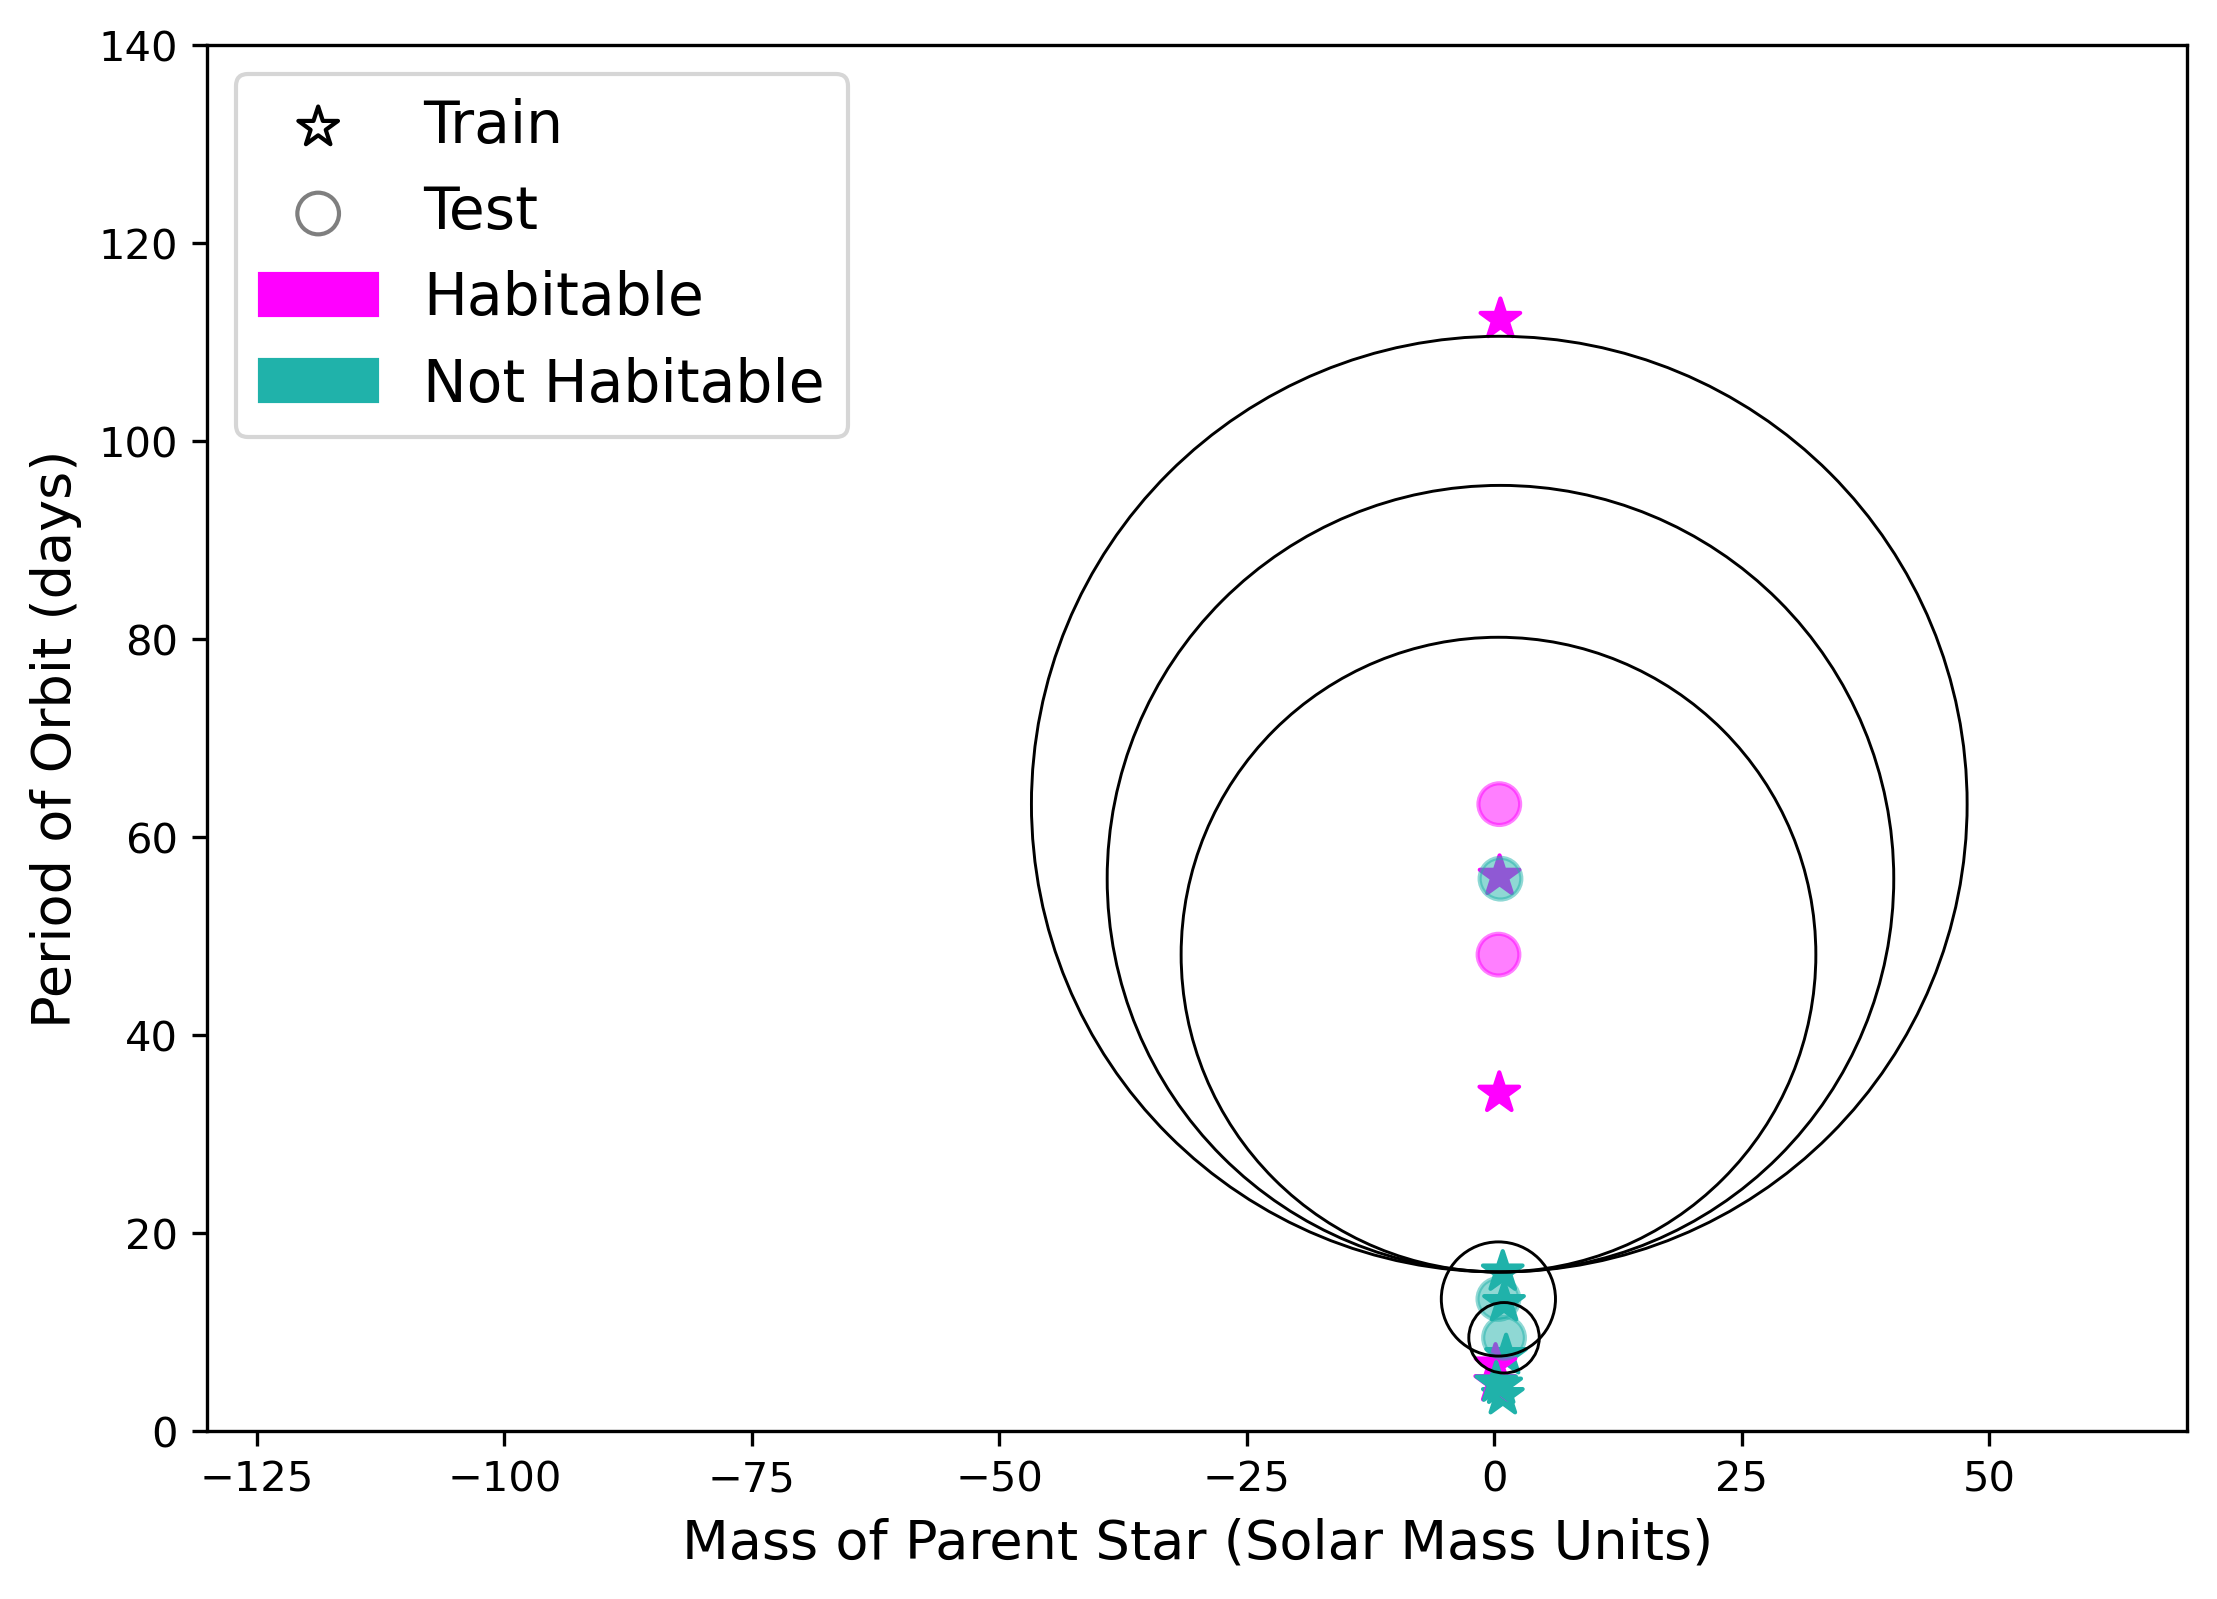

In [304]:
plt.figure(figsize=(10,6))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

a= plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',facecolor = 'None',\
            c = TrainSet['P_HABITABLE'], s = 100, label = 'Train', cmap=cmap) 

#a.set_facecolor('none')


a= plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',facecolor = 'None',\
            c = TestSet['P_HABITABLE'], s = 100, label = 'Test', cmap=cmap, alpha=0.5) 

#a.set_facecolor('none')

for i in range(len(TestSet)): #plot neighbors

    circle1=plt.Circle((TestSet['S_MASS'].iloc[i],TestSet['P_PERIOD'].iloc[i]),model.kneighbors(Xtest.iloc[:,:2])[0][i,2],\
                       lw = 0.7, edgecolor='k',facecolor='none')
    plt.gca().add_artist(circle1)
    
plt.gca().set_aspect(1)

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()
leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[0].set_facecolor('none')
leg.legend_handles[1].set_color('k')
leg.legend_handles[1].set_facecolor('none')


plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14)

plt.xlim(-130,70)
plt.ylim(0,140)
plt.xlabel('Mass of Parent Star (Solar Mass Units)')
plt.ylabel('Period of Orbit (days)');

#plt.savefig('HabPlanetsKNN2features.png', dpi = 300)

### Nota algo particular en el gráfico
Algo particular es que la búsqueda se hace a través del set de train y test considerando que el set de entrenamiento es muy pequeño, entonces se utilizan menos cantidad de neighbors. También los períodos consideran valores "normales" para esa búsqueda de datos k, pero si es mucho mayor serían valores más grandes. Luego, considerando el hint que se da, en la dimensión se tiene un rango muy grande que otras dimensiones locales o más lejanas, lo que conllevará a que domine en el proceso de decisión, pues ni se alcanzan a ver por las escalas grandes. Esto se soluciona a través del escalado, que es fundamental para varios algoritmos de aprendizaje automático. 


Algunos ejemplos de algoritmos de Scaler [aquí](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html).

Usaremos [`RobustScaler()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html), que se comporta mejor con outliers que la versión estándar, ya que escala de acuerdo a percentiles. Específicamente, usa la mediana (percentil 50) y el rango intercuartílico (IQR = Q3 - Q1), lo cual lo hace menos sensible a valores extremos


In [263]:
scaler = sklearn.preprocessing.RobustScaler() #inicializamos el Scaler

#### Importante!!

Debemos ajustar el escalador **sólo con los datos de entrenamiento**. Esto se hace porque **el modelo no debe tener acceso a los datos de prueba durante el entrenamiento**. Si usamos los datos de prueba para ajustar el escalador, estaríamos filtrando información del futuro, lo que se conoce como data leakage.

Esto puede llevar a dos problemas: por un lado, el modelo podría parecer más preciso de lo que realmente es, y por otro, podría aprender patrones que no se generalizan bien a datos nuevos, lo que se traduce en sobreajuste.

Para evitar esto, primero se ajusta el escalador con los datos de entrenamiento (`fit`), y luego se usa ese mismo escalador para transformar tanto el entrenamiento como el test (`transform`).

In [264]:
#el paso de escalamiento solo se hace para el set de entrenamiento
scaler.fit(Xtrain) 

RobustScaler()

In [265]:
#Como los rangos se reescalan, eso se aplica para todo
scaledXTrain = scaler.transform(Xtrain)

In [266]:
scaledXTrain, scaledXTest

(array([[ 0.47222222, -0.18360363, -0.33840183],
        [ 0.44444444,  0.06038761,  0.05671512],
        [ 1.38888889, -0.10467304, -0.14339694],
        [-0.22222222,  1.94175736,  1.60417741],
        [ 0.80555556,  0.        ,  0.        ],
        [-1.66666667, -0.15801948, -0.43679409],
        [ 0.        , -0.16299717, -0.31519247],
        [-1.58333333, -0.12323674, -0.38472405],
        [ 1.19444444, 21.311672  , 11.01745224],
        [ 0.33333333,  3.04655169,  2.38937206],
        [-0.52777778,  0.41352236,  0.3761471 ],
        [-0.44444444,  0.84198052,  0.66159817],
        [-1.41666667, -0.15877753, -0.40201197]]),
 array([[-0.19444444,  0.8370915 ,  0.81076169],
        [-0.77777778,  0.00703724, -0.10517751],
        [-0.52777778,  0.98432221,  0.85796876],
        [ 0.80555556, -0.06956397, -0.10258941],
        [-0.75      ,  0.68709948,  0.46718637]]))

In [267]:
scaledXtest = scaler.transform(Xtest) 

In [268]:
scaledXtest

array([[-0.19444444,  0.8370915 ,  0.81076169],
       [-0.77777778,  0.00703724, -0.10517751],
       [-0.52777778,  0.98432221,  0.85796876],
       [ 0.80555556, -0.06956397, -0.10258941],
       [-0.75      ,  0.68709948,  0.46718637]])

In [192]:
scaler.inverse_transform #esto invierte el escalado si es necesario

<bound method RobustScaler.inverse_transform of RobustScaler()>

**Ahora, con los datos escalados, aplique el modelo de kNN inicializado anteriormente, genere las predicciones y genere la misma visualización que en el caso anterior**

In [269]:
#Primero se tiene el Xtrain reescalado
scaledXTrain

array([[ 0.47222222, -0.18360363, -0.33840183],
       [ 0.44444444,  0.06038761,  0.05671512],
       [ 1.38888889, -0.10467304, -0.14339694],
       [-0.22222222,  1.94175736,  1.60417741],
       [ 0.80555556,  0.        ,  0.        ],
       [-1.66666667, -0.15801948, -0.43679409],
       [ 0.        , -0.16299717, -0.31519247],
       [-1.58333333, -0.12323674, -0.38472405],
       [ 1.19444444, 21.311672  , 11.01745224],
       [ 0.33333333,  3.04655169,  2.38937206],
       [-0.52777778,  0.41352236,  0.3761471 ],
       [-0.44444444,  0.84198052,  0.66159817],
       [-1.41666667, -0.15877753, -0.40201197]])

In [270]:
#El modelo escalado
model_scaled = neighbors.KNeighborsClassifier(n_neighbors = 3)

In [271]:
model_scaled

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None


In [272]:
scaledXTrain[:, :2]

array([[ 0.47222222, -0.18360363],
       [ 0.44444444,  0.06038761],
       [ 1.38888889, -0.10467304],
       [-0.22222222,  1.94175736],
       [ 0.80555556,  0.        ],
       [-1.66666667, -0.15801948],
       [ 0.        , -0.16299717],
       [-1.58333333, -0.12323674],
       [ 1.19444444, 21.311672  ],
       [ 0.33333333,  3.04655169],
       [-0.52777778,  0.41352236],
       [-0.44444444,  0.84198052],
       [-1.41666667, -0.15877753]])

In [273]:
model_scaled.fit(scaledXTrain[:,:2], ytrain) #esto ajusta el modelo que se usa para hacer predicciones en nuevas instancias
ytestpred = model_scaled.predict(scaledXtest[:,:2])

In [274]:
ytestpred, ytest.values #comparacion

(array([1, 0, 1, 0, 1]), array([0, 0, 1, 0, 1]))

In [275]:
print(metrics.accuracy_score(ytrain, model_scaled.predict(scaledXTrain[:, :2]))) #Esto compara las etiquetas reales del set de entrenamiento con las etiquetas predichas para el test de entrenamiento
print(metrics.accuracy_score(ytest, model_scaled.predict(scaledXtest[:,:2])))

0.8461538461538461
0.8


In [276]:
model_scaled.kneighbors(scaledXtest[:,:2])

(array([[0.2500478 , 0.53900086, 1.00570768],
        [0.47721081, 0.66005572, 0.79614695],
        [0.16494121, 0.57079985, 1.00501058],
        [0.06956397, 0.35230123, 0.38378203],
        [0.34256727, 0.35245873, 1.07701084]]),
 array([[11, 10,  1],
        [10, 12,  6],
        [11, 10,  3],
        [ 4,  0,  1],
        [11, 10, 12]]))

In [277]:
for i in range(len(TestSet)): # para cada elemento del set de prueba
    print(model_scaled.kneighbors(scaledXtest[:,:2])[0][i,2]) 

1.0057076822074733
0.7961469534072081
1.0050105812138872
0.3837820313273946
1.0770108415685602


In [278]:
TestSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
13,HD 104067 b,0.62,55.80600,0.260000,0
14,GJ 4276 b,0.41,13.35200,0.087613,0
15,Kepler-296 f,0.50,63.33627,0.268885,1
16,Kepler-63 b,0.98,9.43415,0.088100,0
17,GJ 3293 d,0.42,48.13450,0.195336,1


/var/folders/36/rk32flss4bj4sbk5qc_2v8l00000gn/T/ipykernel_25699/1609464277.py:5: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  plt.scatter(
/var/folders/36/rk32flss4bj4sbk5qc_2v8l00000gn/T/ipykernel_25699/1609464277.py:17: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  plt.scatter(


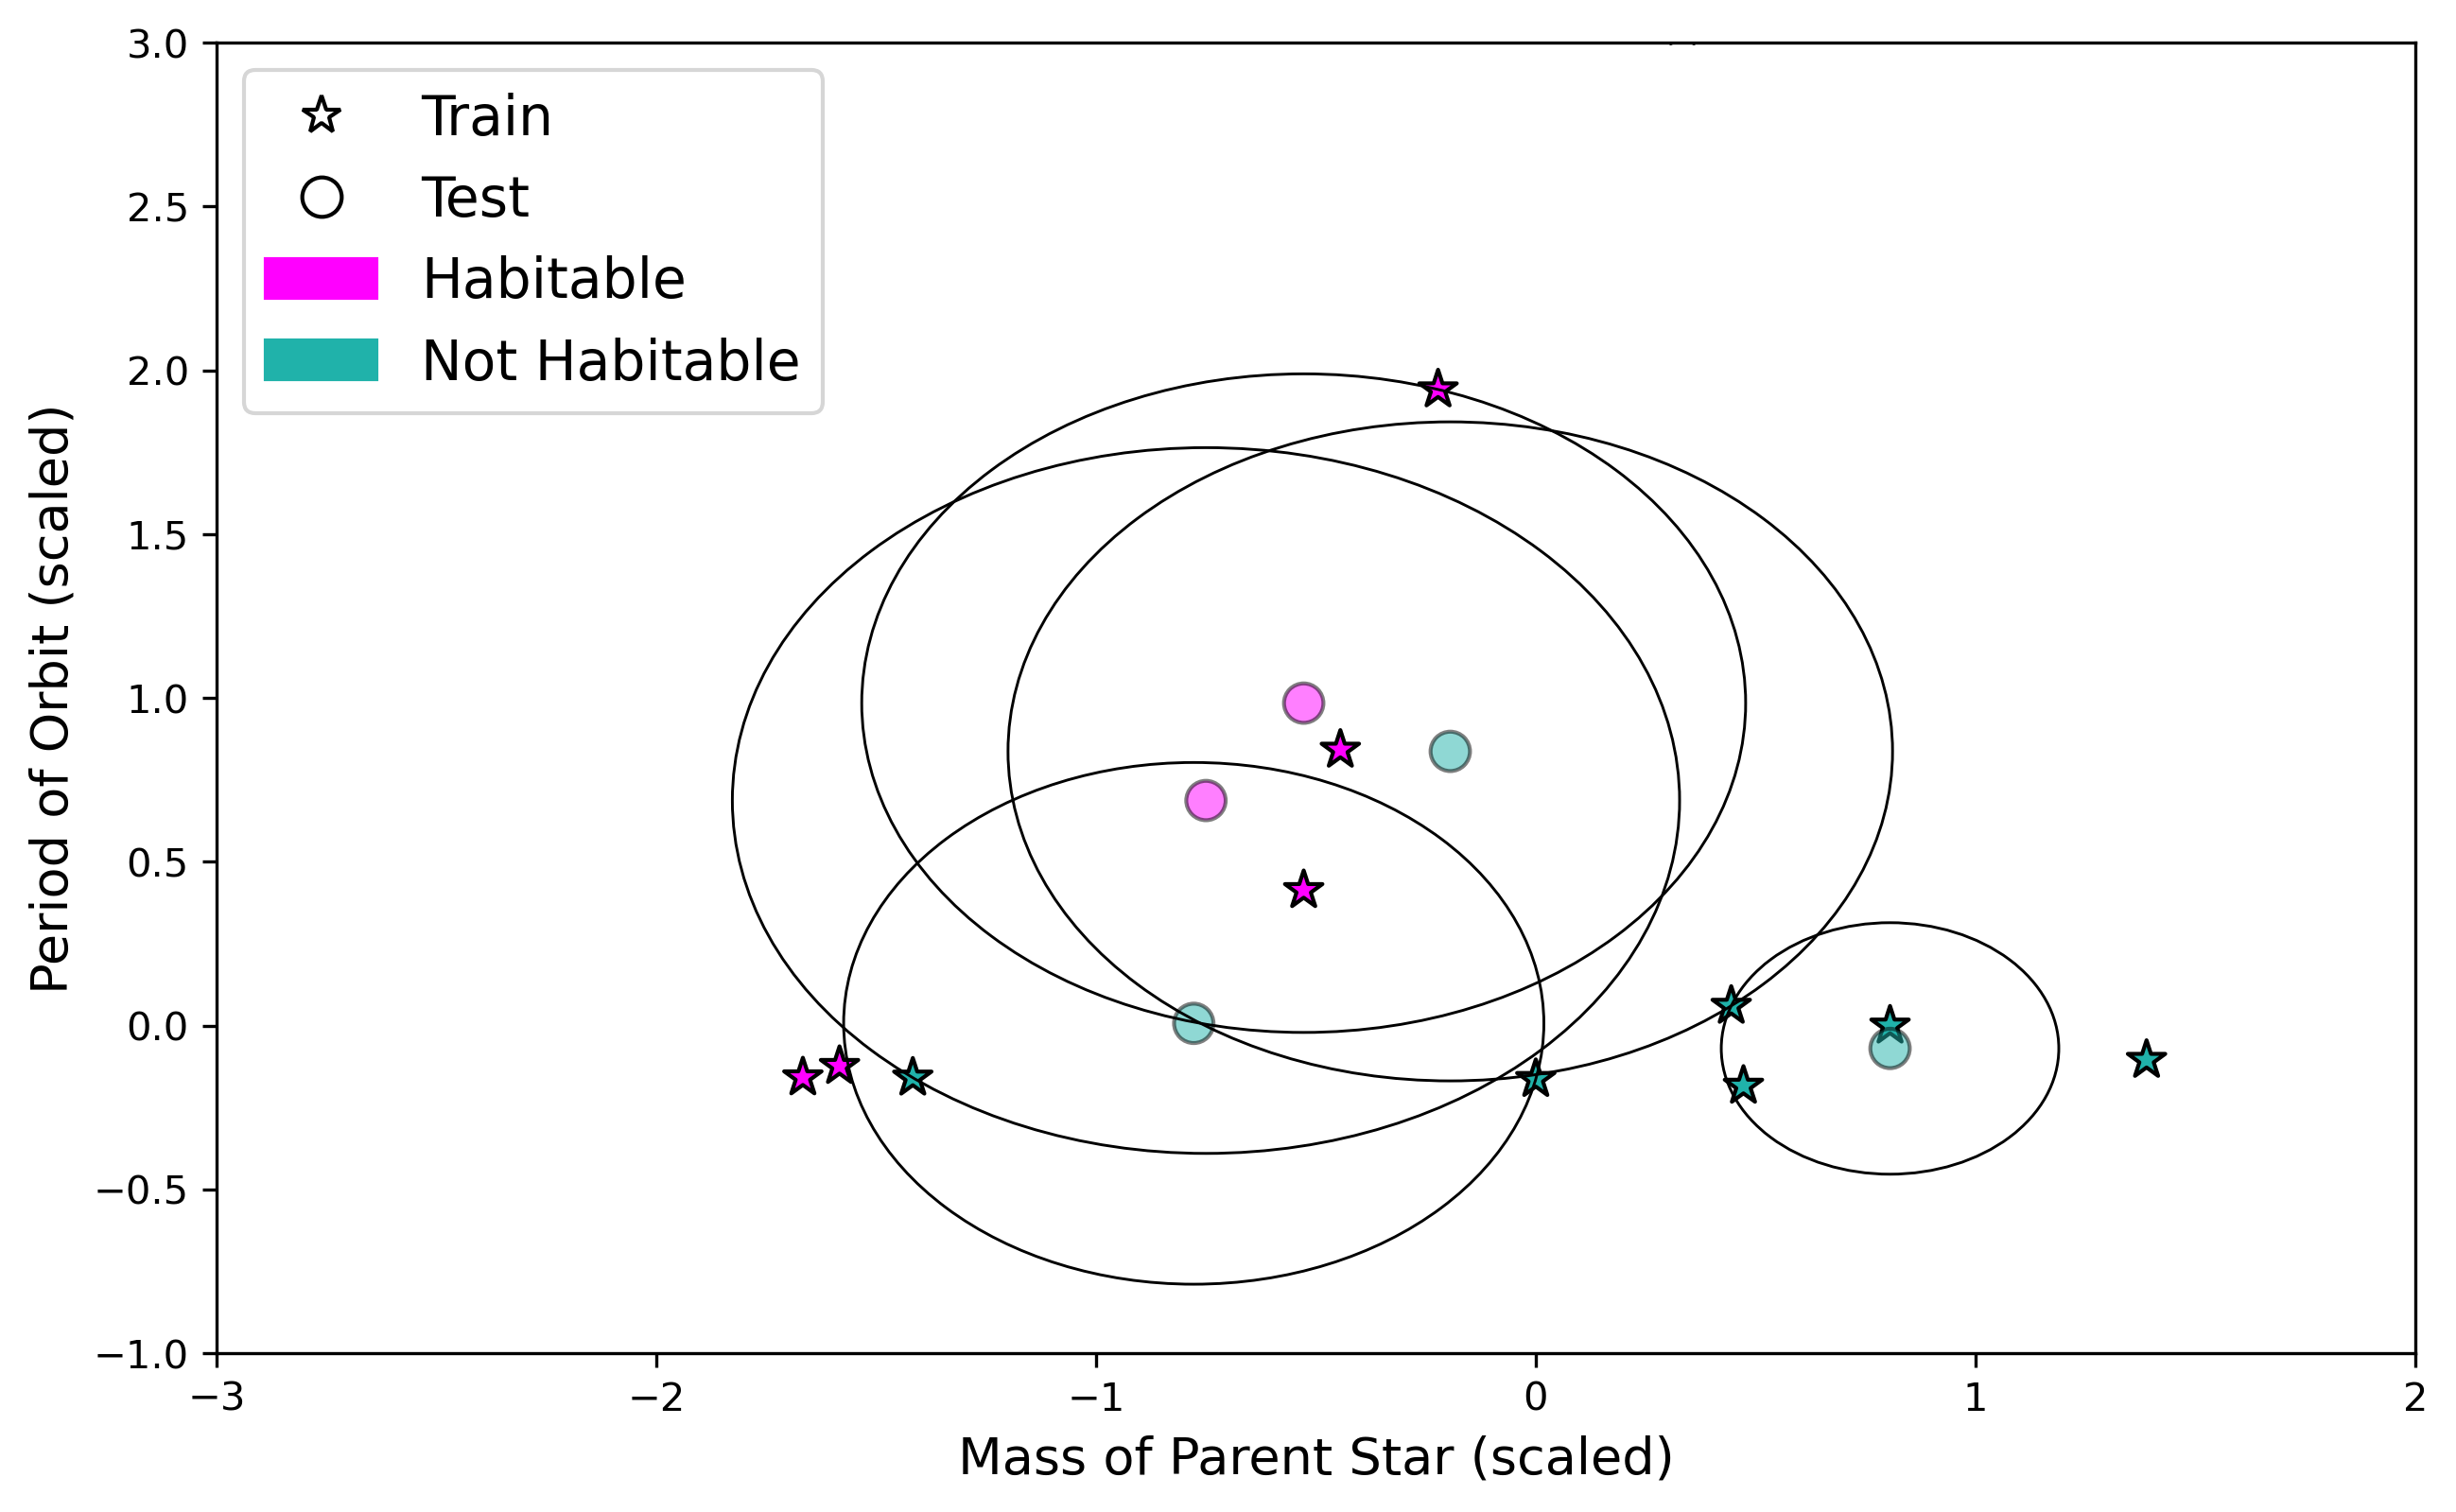

In [292]:
#en esta parte tuve que buscar por internet el como hacer que aparecieran los circulos para el escalamiento, pues me salía error antes
plt.figure(figsize=(10,6))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA', '#FF00FF'])
#aquí van set escalado de entrenamiento
plt.scatter(
    scaledXTrain[:, 0],
    scaledXTrain[:, 1],
    marker='*',
    facecolor='none',
    edgecolor='k',
    c=TrainSet['P_HABITABLE'],
    s=100,
    label='Train',
    cmap=cmap
)
#aquí va el set escalado de prueba
plt.scatter(
    scaledXtest[:, 0],
    scaledXtest[:, 1],
    marker='o',
    facecolor='none',
    edgecolor='k',
    c=TestSet['P_HABITABLE'],
    s=100,
    label='Test',
    cmap=cmap,
    alpha=0.5
)
distances, indices = model_scaled.kneighbors(scaledXtest[:, :2])
for i in range(len(TestSet)):
    circle = plt.Circle(
        (scaledXtest[i, 0], scaledXtest[i, 1]),
        distances[i, 2],
        lw=0.7,
        edgecolor='k',
        facecolor='none'
    )
    plt.gca().add_artist(circle)
plt.xlabel('Mass of Parent Star (scaled)')
plt.ylabel('Period of Orbit (scaled)')

bluepatch = mpatches.Patch(
    color='#20B2AA',
    label='Not Habitable'
)
magentapatch = mpatches.Patch(
    color='#FF00FF',
    label='Habitable'
)
plt.legend(
    handles=[
        plt.Line2D(
            [], [], marker='*', color='k',
            markerfacecolor='none',
            linestyle='None',
            markersize=10,
            label='Train'
        ),
        plt.Line2D(
            [], [], marker='o', color='k',
            markerfacecolor='none',
            linestyle='None',
            markersize=10,
            label='Test'
        ),
        magentapatch,
        bluepatch
    ],
    loc='upper left',
    fontsize=14
)

plt.xlim(-3, 2)
plt.ylim(-1, 3)
plt.show()

En la gráfica se observa distintos radios que encierran a los 3 vecinos más cercanos para cada elemento del set de prueba, con el escalamiento aplicado, de manera que la clasificación no cambia, solo se hizo un "zoom". En general, para el algoritmo de kNN 

**Repitiendo el proceso de kNN escalado, pero usando todas las caracteristicas, y comparando el accuracy**

In [310]:
#haciendo uso de todas las características
model_scaled_all = KNeighborsClassifier(n_neighbors=3)
# El modelo se entrena usando todas las características
#para así construir el modelo y predecir el método en un set de prueba
model_scaled_all.fit(scaledXTrain, ytrain)
ytestpred_all = model_scaled_all.predict(scaledXtest) #se predice usando los datos de prueba ya escalados
accuracy_all = metrics.accuracy_score(ytest, ytestpred_all) #accuracy_score(ytest, ytestpred_all)
print("Accuracy (con todas las features):", accuracy_all)

Accuracy (con todas las features): 0.8


In [311]:
accuracy_two = accuracy_score(ytest, ytestpred)
print("Accuracy con 2 de 3 features:", accuracy_two)
print("Accuracy con todas las features:", accuracy_all)

Accuracy con 2 de 3 features: 0.8
Accuracy con todas las features: 0.8


Como se puede ver para el accuracy, tanto para 2 y 3 características da 80% de clasificaciones correctas, luego significaría que las características adicionales no aportan información útil, sigue siendo el mismo accuracy de acierto en la clasificación. Para el caso del primer gráfico, se puede tener en cuenta que un 80% de accuracy no es tan malo, debido a que se tiene una muestra pequeña, pero si que tienen impacto las escalas mismas tanto del período orbital y masa estelar, cuyos promedios son 14.7 días y 0.61 solar mass, respectivamente.
Pero a pesar de que los accuracy no cambian, esto es considerada una anomalía que depende del tamaño del data set.

### Preguntas como seguimiento de conclusiones

- Descubrimos que kNN necesita escalado ¿DT (decision tree) tiene el mismo problema?

No, el DT no necesita escalado, puesto que permite todo rango para tomar decisiones, pues el algoritmo DT va dividiendo por cada feature al mismo tiempo, donde la escala de cada una es independiente de la otra.
- Compare las fortalezas y debilidades de DT y kNN

Los árboles de decisión resultan ser relativamente compactos y simples de interpretar, puesto que las características del sistema están siendo mostradas todas a la vez, luego se permiten distintos rangos, además como se vio en el segundo set de datos, para el árbol de decisión que es arbitrariamente profundo siempre se logrará un "rendimiento" perfecto, lo que se muestra como gini=0, pero no es representativo en su totalidad, pues no permite generalizar las salidas, debido a que los splits se hacen solo en base a los elementos que conforman sus características iniciales u originales. Luego, se requiere la determinación de las características antes de construir el modelo. Por otra parte, se tiene que el algoritmo de kNN resulta también simple para poder clasificar y ser aplicable en problemas de regresión, además de poderse interpretar, pero es sensible a la característica de escala y consigo, sensible a distintas escalas, que requiere de revisión de todas las características del sistema para que puedan presentarse igualmente. Entonces es sensible al tamaño y densidad del set de entrenamiento. Tiene a su disposición pocos ejemplos de entrenamiento y dependiendo de las distancias entre los elementos del conjunto de prueba, se considera el método de distancia basado en ejemplos que se encuentran a grandes distancias, pero como se había mencionado más arriba, se pueden considerar neighbors en radios fijos como locales, involucrando también números fijos.

- ¿Qué diferencia conceptual hay entre cómo clasifica un árbol de decisión y cómo clasifica kNN? La forma en que clasifica un árbol de decisiones es priorizar las características consideradas. Esto es, si en las columnas en el set (como por ejemplo al visualizar la tabla LearningSet) no existe algún dato, este es ignorado, dado que cuando se realicen las divisiones en determinadas direcciones, las impurezas del gini no se verán disminuidas. Respecto al método kNN, de igual forma considera las características del sistema debido al cálculo de distancias en todo lo que conforma el data, como en todas las dimensiones del data. Aunque el kNN puede verse afectado por características que no se utilicen o también que sean redundantes, porque hace que el método pierda precisión debido a que no se prioriza lo que realmente interesa ver y analizar.

- ¿Por qué el accuracy en entrenamiento no basta para evaluar un modelo? Porque si es entrenado, puede serlo muchas veces provocando un leaf perfecto al final de los splits, lo que puede sobreajustar. Dado que con solo el accuracy no es suficiente, además de que no significa que un accuracy alto sea representativo y consecuentemente que se pueda generalizar sobre el resultado final, se tiene que tomar en cuenta el modelo que se genera con el conjunto de prueba para observar cambios y poder extraer nuevas conclusiones.

- ¿Por qué kNN requiere escalamiento y un árbol de decisión no necesariamente? Porque se permite una comparación de las características del sistema, debido a que grandes rangos pueden dominar en la clasificación, y de hecho el como se clasifiquen los features las diferencias pueden llegar a ser despreciables, por eso se requiere la estandarización, que inicialmente como concepto se realiza calculando el promedio y desviación estándar para cada feature para el escalamiento, pero se vuelve muy sensible a los outliers como por ejemplo el el gráfico primero de kNN para el objeto con mucho período orbital, y para ello se hace el preprocesamiento, que es una técnica de escalamiento más robusta en relación a la estandarización, tomando en cuenta la mediana debido a que es menos sensible a outliers, a 0 y Q1-Q3 a 1. Por otra parte, el árbol de decisión considerar distintas medidas y de igual forma hará splits de los que se puedan extraer información sin ser su contenido afectado.

- Si tuvieras que elegir uno de los dos métodos para este dataset pequeño, ¿cuál elegirías y por qué? Se podría escoger el árbol de decisiones, porque como se había mencionado el kNN puede perder precisión y además necesita escalamiento de datos, en cambio de DT muestra cada "paso" de cómo se toma en cuenta una característica determinada con relativa precisión en la toma de decisión.